# Pràctica 4 — Similitud Lèxica i Semàntica

Entrenament i avaluació de models d'embeddings distribucionals i contextuals per a tasques de similitud en espanyol.

**Datasets**
- **Multi-SimLex (Spanish)** — parells de paraules → avaluació *intrínseca* (Spearman)
- **Spanish STS (PlanTL-GOB-ES)** — parells de frases → avaluació *extrínseca* (Pearson)
- **Wikicorpus** en espanyol per entrenar embeddings

## 0. Setup

Instal·lacions, imports i configuració global.

In [1]:
# Instal·la dependències
# !pip install -q gensim==4.3.* transformers datasets torch scikit-learn pandas tqdm huggingface_hub

In [2]:
import os
import re
import gzip
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr, spearmanr

# Reproductibilitat
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositiu: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositiu: cuda
PyTorch: 2.11.0+cu128


In [3]:
# Constants i directoris

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Hiperparàmetres globals per a models Word2Vec i fastText (Tasques 1 i 2)
W2V_DIMS = [50, 100, 200, 300, 400]   
FT_DIMS = [50, 100, 200, 300]
FT_DIM  = 300    # dimensió del ft_propi (= ft_ablation["all"], FT_ABLATION_DIM)                  
W2V_EPOCHS = 10
W2V_WINDOW = 5
W2V_MIN_COUNT = 5

# Hiperparàmetres dels models neurals (Tasques 3+)
MAX_LEN_SEQ = 64
BATCH_SIZE = 32
SIAMESE_EPOCHS = 10
SIAMESE_LR = 1e-3
BERT_EPOCHS = 4
BERT_LR = 2e-5
BERT_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO


## 1. Descàrrega, càrrega i inspecció de dades

Tres fonts: el Wikicorpus per entrenar embeddings, Spanish STS per a l'avaluació extrínseca, i Multi-SimLex per a l'avaluació intrínseca.

### 1.1 Wikicorpus

In [5]:
import urllib.request
import tarfile

WIKI_URL = "https://www.cs.upc.edu/~nlp/wikicorpus/raw.es.tgz"
WIKI_TGZ = DATA_DIR / "raw.es.tgz"
WIKI_DIR = DATA_DIR / "raw.es"

if not WIKI_TGZ.exists() or WIKI_TGZ.stat().st_size < 100_000_000:
    print("Descarregant Wikicorpus...")
    urllib.request.urlretrieve(WIKI_URL, WIKI_TGZ)
print(f"Carregat: {WIKI_TGZ}  ({WIKI_TGZ.stat().st_size:,} bytes)")

WIKI_DIR.mkdir(exist_ok=True)
if not any(p.is_file() for p in WIKI_DIR.rglob("*")):
    print("Descomprimint...")
    with tarfile.open(WIKI_TGZ, "r:gz") as tar:
        tar.extractall(WIKI_DIR, filter="data")
    print("Extracció completa")

files = [p for p in WIKI_DIR.rglob("*") if p.is_file()]
print(f"Total fitxers extrets: {len(files)}")

Carregat: data\raw.es.tgz  (252,926,918 bytes)
Total fitxers extrets: 57


#### Tokenitzador i càrrega de frases

In [6]:
# Tokenitzador
# Preprocess: minúscules, extracció de tokens alfanumèrics, filtre de frases curtes (min_tokens=3) i min_count=5

WORD_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)

def tokenize(text):
    return WORD_RE.findall(text.lower())

def iter_wikicorpus_sentences(wiki_dir, max_sentences=None, min_tokens=3):
    """Itera sobre frases tokenitzades del Wikicorpus en streaming."""
    sent_split = re.compile(r"[.!?¡¿]+")
    n = 0
    files = sorted(p for p in Path(wiki_dir).rglob("*") if p.is_file())
    for fp in files:
        try:
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("<doc") \
                       or line.startswith("</doc") \
                       or line.startswith("ENDOFARTICLE"):
                        continue
                    for sent in sent_split.split(line):
                        toks = tokenize(sent)
                        if len(toks) >= min_tokens:
                            yield toks
                            n += 1
                            if max_sentences is not None and n >= max_sentences:
                                return
        except Exception:
            continue

In [6]:
# Càrrega de sentences (corpus complet)
from collections import Counter

sentences = list(iter_wikicorpus_sentences(WIKI_DIR, max_sentences=None))

all_tokens   = [tok for sent in sentences for tok in sent]
vocab_counter = Counter(all_tokens)
vocab_above  = sum(1 for f in vocab_counter.values() if f >= W2V_MIN_COUNT)

print(f"Frases           : {len(sentences):,}")
print(f"Tokens totals    : {len(all_tokens):,}")
print(f"Vocabulari únic  : {len(vocab_counter):,}")
print(f"Longitud mitjana : {len(all_tokens)/len(sentences):.1f} toks/frase")
print(f"Paraules >= min_count={W2V_MIN_COUNT}: {vocab_above:,} ({vocab_above/len(vocab_counter)*100:.1f}%)")
print(f"Top-10 paraules  : {vocab_counter.most_common(10)}")

Frases           : 5,847,015
Tokens totals    : 101,786,019
Vocabulari únic  : 1,122,904
Longitud mitjana : 17.4 toks/frase
Paraules >= min_count=5: 296,763 (26.4%)
Top-10 paraules  : [('de', 7764258), ('la', 4051799), ('en', 3384154), ('el', 3058034), ('y', 2645922), ('a', 1792421), ('que', 1682921), ('los', 1451190), ('del', 1390945), ('se', 1163272)]


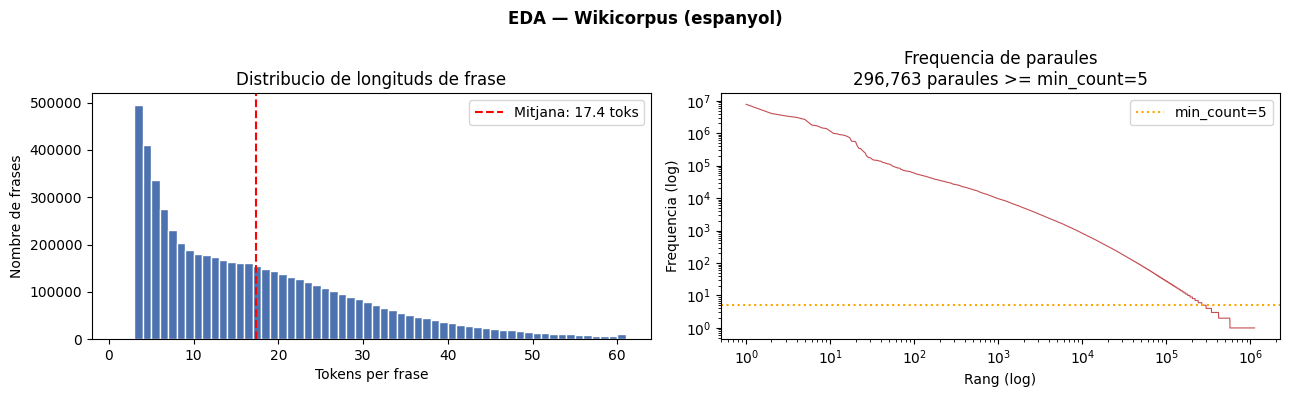

Frases amb >60 tokens (no mostrades al histograma): 1.3%


In [7]:
import matplotlib.pyplot as plt

sent_lengths = [len(s) for s in sentences]
mean_len = sum(sent_lengths) / len(sent_lengths)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("EDA — Wikicorpus (espanyol)", fontweight="bold")

# Esquerra: histograma de longituds de frase
# frases >60 toks s'ometen del grafic
axes[0].hist(sent_lengths, bins=range(1, 62), color="#4C72B0", edgecolor="white")
axes[0].axvline(mean_len, color="red", linestyle="--",
                label=f"Mitjana: {mean_len:.1f} toks")
axes[0].set_title("Distribucio de longituds de frase")
axes[0].set_xlabel("Tokens per frase")
axes[0].set_ylabel("Nombre de frases")
axes[0].legend()

# Dreta: Rang vs frequencia, escala log-log
freqs = sorted(vocab_counter.values(), reverse=True)
axes[1].loglog(range(1, len(freqs)+1), freqs, color="#C44E52", linewidth=0.8)
axes[1].axhline(W2V_MIN_COUNT, color="orange", linestyle=":",
                linewidth=1.5, label=f"min_count={W2V_MIN_COUNT}")
axes[1].set_title(f"Frequencia de paraules\n"
                  f"{vocab_above:,} paraules >= min_count={W2V_MIN_COUNT}")
axes[1].set_xlabel("Rang (log)")
axes[1].set_ylabel("Frequencia (log)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_wikicorpus.png", dpi=150, bbox_inches="tight")
plt.show()

pct_over60 = sum(1 for l in sent_lengths if l > 60) / len(sent_lengths) * 100
print(f"Frases amb >60 tokens (no mostrades al histograma): {pct_over60:.1f}%")

### 1.2 Spanish STS

In [9]:
from datasets import load_dataset

sts = load_dataset("PlanTL-GOB-ES/sts-es")
print(sts)

train_df = sts["train"].to_pandas()
dev_df   = sts["validation"].to_pandas()
test_df  = sts["test"].to_pandas()

for df in [train_df, dev_df, test_df]:
    if "label" in df.columns and "score" not in df.columns:
        df.rename(columns={"label": "score"}, inplace=True)

print(f"\nTrain: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
print(train_df.head(3))

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 1320
    })
    validation: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 77
    })
    test: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 155
    })
})

Train: 1320 | Dev: 77 | Test: 155
  id                                          sentence1  \
0  0  Según el sondeo, 87% de los católicos cree que...   
1  1  La psicología explora conceptos como la percep...   
2  2  La tradición comenzó en el siglo IV, pero la m...   

                                           sentence2  score  
0  El 87% de los católicos del mundo aprobaron el...   3.75  
1  La "psicología básica" es la parte de la psico...   2.80  
2  La tradición de erigir piedras con inscripcion...   2.40  


C:\Users\irenm\AppData\Local\Temp\ipykernel_4160\3160375192.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([df_s["score"].values for df_s in splits.values()],


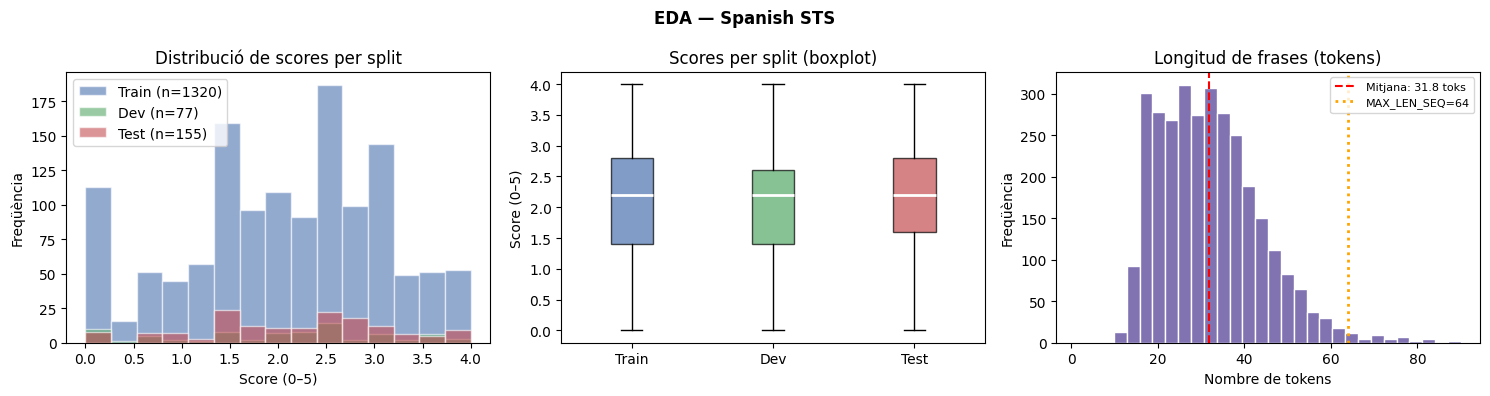

Split        N    min   max   mitjà   long. frase mitjana
----------------------------------------------------------
Train     1320    0.0   4.0   2.075                  31.9
Dev         77    0.0   4.0   2.012                  30.5
Test       155    0.0   4.0   2.161                  31.8

Frases > MAX_LEN_SEQ (64): 35 (1.1%) → seran truncades


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Spanish STS", fontweight="bold")

colors = {"Train": "#4C72B0", "Dev": "#55A868", "Test": "#C44E52"}
splits = {"Train": train_df,   "Dev": dev_df,    "Test": test_df}

for name, df_s in splits.items():
    axes[0].hist(df_s["score"], bins=15, alpha=0.6,
                 label=f"{name} (n={len(df_s)})", color=colors[name], edgecolor="white")
axes[0].set_title("Distribució de scores per split")
axes[0].set_xlabel("Score (0–5)")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

bp = axes[1].boxplot([df_s["score"].values for df_s in splits.values()],
                     labels=splits.keys(), patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Scores per split (boxplot)")
axes[1].set_ylabel("Score (0–5)")

all_sents = pd.concat([df_s[col] for df_s in splits.values()
                        for col in ["sentence1", "sentence2"]])
lengths = all_sents.str.split().apply(len)
axes[2].hist(lengths, bins=30, color="#8172B2", edgecolor="white")
axes[2].axvline(lengths.mean(), color="red", linestyle="--",
                label=f"Mitjana: {lengths.mean():.1f} toks")
axes[2].axvline(MAX_LEN_SEQ, color="orange", linestyle=":",
                linewidth=2, label=f"MAX_LEN_SEQ={MAX_LEN_SEQ}")
axes[2].set_title("Longitud de frases (tokens)")
axes[2].set_xlabel("Nombre de tokens")
axes[2].set_ylabel("Freqüència")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_sts.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Split':<8} {'N':>5}  {'min':>5} {'max':>5} {'mitjà':>7}  {'long. frase mitjana':>20}")
print("-" * 58)
for name, df_s in splits.items():
    lens = pd.concat([df_s["sentence1"], df_s["sentence2"]]).str.split().apply(len)
    print(f"{name:<8} {len(df_s):>5}  {df_s['score'].min():>5.1f} "
          f"{df_s['score'].max():>5.1f} {df_s['score'].mean():>7.3f}  "
          f"{lens.mean():>20.1f}")
pct = (lengths > MAX_LEN_SEQ).mean() * 100
print(f"\nFrases > MAX_LEN_SEQ ({MAX_LEN_SEQ}): "
      f"{(lengths > MAX_LEN_SEQ).sum()} ({pct:.1f}%) → seran truncades")

In [11]:
# Vocabulari únic del corpus STS 
# Per estimar la cobertura dels embeddings sobre el conjunt d'avaluació
all_words_sts = set()
word_freq_sts  = Counter()
for df_s in [train_df, dev_df, test_df]:
    for col in ["sentence1", "sentence2"]:
        for sent in df_s[col]:
            toks = tokenize(sent)
            all_words_sts.update(toks)
            word_freq_sts.update(toks)

n_frases = sum(len(df_s) * 2 for df_s in [train_df, dev_df, test_df])
print(f"Frases totals (tots els splits) : {n_frases:,}")
print(f"Vocabulari únic al corpus STS   : {len(all_words_sts):,} paraules")
print(f"Top-10 paraules més freqüents   : {word_freq_sts.most_common(10)}")

Frases totals (tots els splits) : 3,104
Vocabulari únic al corpus STS   : 11,904 paraules
Top-10 paraules més freqüents   : [('de', 8902), ('la', 5184), ('el', 3849), ('en', 3048), ('que', 2322), ('y', 2310), ('a', 1946), ('los', 1642), ('del', 1464), ('un', 1213)]


### 1.3 Multi-SimLex (Spanish)

In [8]:
import urllib.request

MULTISIMLEX_PATH = DATA_DIR / "multisimlex_spa.csv"
MULTISIMLEX_URL  = "https://web.archive.org/web/20231020014354id_/https://multisimlex.com/data/SPA.csv"

if not MULTISIMLEX_PATH.exists():
    urllib.request.urlretrieve(MULTISIMLEX_URL, MULTISIMLEX_PATH)

# Inspecció format: "ID, Word_1, Word_2..."
print(MULTISIMLEX_PATH.read_text(encoding="utf-8")[:500])

ID,Word 1,Word 2,PoS,Annotator 1,Annotator 2,Annotator 3,Annotator 4,Annotator 5,Annotator 6,Annotator 7,Annotator 8,Annotator 9,Annotator 10
1,brazo,músculo,nouns,1,1,5,0,0,0,2,1,2,2
2,democracia,monarquía,nouns,0,0,3,0,0,0,2,1,3,4
3,tejado,techo,nouns,5,5,6,4,5,3,4,4,6,6
4,amigo,profesor,nouns,0,0,1,0,0,0,2,0,1,0
5,mano,pie,nouns,1,0,3,0,0,0,2,1,3,1
6,biografía,ficción,nouns,1,1,2,0,0,0,0,0,2,1
7,disco,ordenador,nouns,0,1,4,0,0,0,2,2,1,3
8,Esgrima,gimnasia,nouns,1,2,6,2,3,0,3,1,4,4
9,banco,asi


In [9]:
multisimlex_df = pd.read_csv(MULTISIMLEX_PATH, sep=",")

cols_lower = {c.lower(): c for c in multisimlex_df.columns}

def find_col(candidates):
    for n in candidates:
        if n.lower() in cols_lower:
            return cols_lower[n.lower()]
    return None

W1_COL    = find_col(["word1", "word 1", "word_1", "w1"])
W2_COL    = find_col(["word2", "word 2", "word_2", "w2"])
SCORE_COL = find_col(["score", "mean", "similarity", "rating"])

# Multi-SimLex (Spanish) no té score precalculat:
# calculem la mitjana dels 10 anotadors
if SCORE_COL is None:
    annotator_cols = [c for c in multisimlex_df.columns if c.lower().startswith("annotator")]
    multisimlex_df["score"] = multisimlex_df[annotator_cols].mean(axis=1)
    SCORE_COL = "score"

multisimlex_pairs = list(zip(
    multisimlex_df[W1_COL].astype(str).str.lower(),
    multisimlex_df[W2_COL].astype(str).str.lower(),
    multisimlex_df[SCORE_COL].astype(float),
))

print(f"Total parells Multi-SimLex: {len(multisimlex_pairs)}")
print("Exemples:", multisimlex_pairs[:3])

Total parells Multi-SimLex: 1888
Exemples: [('brazo', 'músculo', 1.4), ('democracia', 'monarquía', 1.3), ('tejado', 'techo', 4.8)]


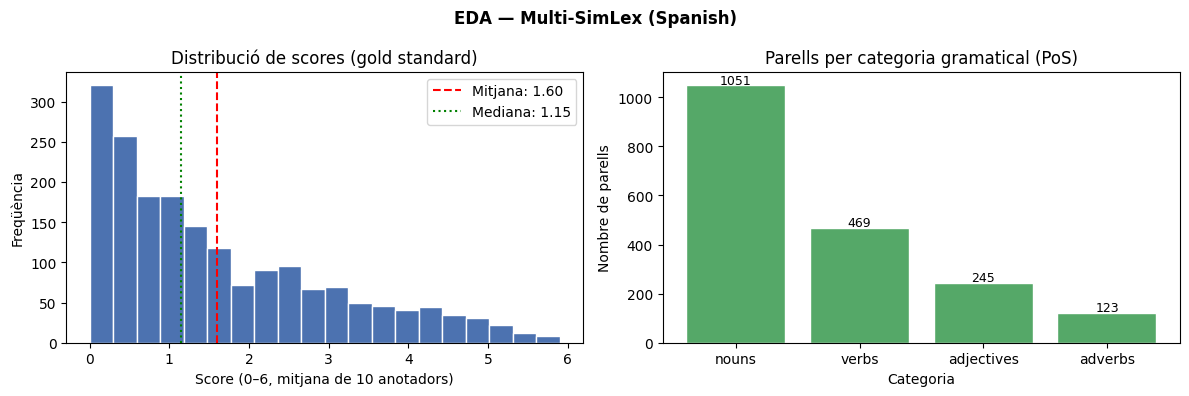

Parells totals     : 1,888
Score — mínim: 0.00 | màxim: 5.90 | mitjà: 1.60 | mediana: 1.15 | std: 1.43
Parells score = 0  (no similars) : 98
Parells score ≥ 5  (molt similars): 51


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("EDA — Multi-SimLex (Spanish)", fontweight="bold")

axes[0].hist(multisimlex_df["score"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(multisimlex_df["score"].mean(), color="red", linestyle="--",
                label=f"Mitjana: {multisimlex_df['score'].mean():.2f}")
axes[0].axvline(multisimlex_df["score"].median(), color="green", linestyle=":",
                label=f"Mediana: {multisimlex_df['score'].median():.2f}")
axes[0].set_title("Distribució de scores (gold standard)")
axes[0].set_xlabel("Score (0–6, mitjana de 10 anotadors)")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

pos_counts = multisimlex_df["PoS"].value_counts()
bars = axes[1].bar(pos_counts.index, pos_counts.values, color="#55A868", edgecolor="white")
for bar, v in zip(bars, pos_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha="center", fontsize=9)
axes[1].set_title("Parells per categoria gramatical (PoS)")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Nombre de parells")

plt.tight_layout()
plt.savefig("eda_multisimlex.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Parells totals     : {len(multisimlex_pairs):,}")
print(f"Score — mínim: {multisimlex_df['score'].min():.2f} | "
      f"màxim: {multisimlex_df['score'].max():.2f} | "
      f"mitjà: {multisimlex_df['score'].mean():.2f} | "
      f"mediana: {multisimlex_df['score'].median():.2f} | "
      f"std: {multisimlex_df['score'].std():.2f}")
print(f"Parells score = 0  (no similars) : {(multisimlex_df['score'] == 0).sum()}")
print(f"Parells score ≥ 5  (molt similars): {(multisimlex_df['score'] >= 5).sum()}")

## 2. Tasca 1 — Entrenament d'embeddings estatics

Entrenem embeddings distribucionals sobre el Wikicorpus en espanyol.

**Models entrenats:**
- §2.1 Word2Vec **CBOW** — ablacio de dimensionalitat {50, 100, 200, 300, 400} sobre ~50M tokens
- §2.2 Word2Vec **CBOW** — ablacio de mida del corpus {~10M, ~25M, ~50M, tot} amb dim=300
- §2.3 fastText **CBOW** — ablacio de dimensionalitat {50, 100, 200, 300} sobre ~50M tokens
- §2.4 fastText **CBOW** — ablacio de mida del corpus {~10M, ~25M, ~50M, tot} amb dim=300
- §2.5 Wrappers FastText per a l'avaluacio OOV

**Hiperparametres compartits** (Word2Vec i fastText propi):

| Parametre     | Valor              | Descripcio                          |
|---------------|--------------------|-------------------------------------|
| `sg`          | 0                  | CBOW (prediu paraula central)       |
| `window`      | `W2V_WINDOW` = 5   | Finestra de context (+/-5 paraules) |
| `min_count`   | `W2V_MIN_COUNT` = 5| Descarta paraules amb freq < 5      |
| `epochs`      | `W2V_EPOCHS` = 10  | Passades sobre el corpus            |
| `seed`        | `SEED` = 42        | Reproduibilitat                     |

### 2.1 Word2Vec CBOW — ablacio de dimensionalitat

CBOW prediu la paraula central a partir de les paraules de context.
Comparem quatre dimensions sobre un corpus de referencia de ~50M tokens per aïllar
l'efecte de la dimensionalitat del de la mida del corpus.

| Parametre       | Valor                |
|-----------------|----------------------|
| `vector_size`   | {50, 100, 200, 300, 400}   |
| `window`        | `W2V_WINDOW` = 5     |
| `min_count`     | `W2V_MIN_COUNT` = 5  |
| `epochs`        | `W2V_EPOCHS` = 10    |
| `sg`            | 0 (CBOW)             |
| Corpus          | ~50M tokens          |

In [11]:
from gensim.models import Word2Vec

def sentences_up_to_tokens(sents, target_tokens):
    """Retorna les primeres frases fins acumular ~target_tokens tokens."""
    acc, subset = 0, []
    for s in sents:
        subset.append(s)
        acc += len(s)
        if acc >= target_tokens:
            break
    return subset

REF_TOKENS    = 50_000_000
sentences_50M = sentences_up_to_tokens(sentences, REF_TOKENS)
real_tok_50M  = sum(len(s) for s in sentences_50M)
print(f"Subconjunt de referencia: {len(sentences_50M):,} frases, {real_tok_50M/1e6:.1f}M tokens")

W2V_DIMS = [50, 100, 200, 300, 400]

w2v_models = {}
for dim in W2V_DIMS:
    out_path = MODELS_DIR / f"w2v_cbow_{dim}d.model"
    if out_path.exists():
        m = Word2Vec.load(str(out_path))
        estat = "carregat"
    else:
        m = Word2Vec(
            sentences=sentences_50M,
            vector_size=dim,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
        )
        m.save(str(out_path))
        estat = "entrenat"
    w2v_models[dim] = m
    print(f"  w2v-cbow-{dim:3d}d | {estat:8s} | vocab: {len(m.wv):>6,} | {out_path.name}")

Subconjunt de referencia: 2,822,112 frases, 50.0M tokens
  w2v-cbow- 50d | carregat | vocab: 192,857 | w2v_cbow_50d.model
  w2v-cbow-100d | carregat | vocab: 192,857 | w2v_cbow_100d.model
  w2v-cbow-200d | carregat | vocab: 192,857 | w2v_cbow_200d.model
  w2v-cbow-300d | carregat | vocab: 192,857 | w2v_cbow_300d.model
  w2v-cbow-400d | carregat | vocab: 192,857 | w2v_cbow_400d.model


### 2.2 Word2Vec CBOW — ablacio de mida del corpus

Fixem dim=300 i CBOW, i variem la mida del corpus expressada en tokens acumulats.

El cas `50M` reutilitza el model entrenat a §2.1 (mateixa dimensio i corpus). El cas `all` usa el corpus complet.

| Parametre      | Valor                              |
|----------------|------------------------------------|
| `vector_size`  | `ABLATION_DIM` = 300               |
| `window`       | `W2V_WINDOW` = 5                   |
| `min_count`    | `W2V_MIN_COUNT` = 5                |
| `epochs`       | `W2V_EPOCHS` = 10                  |
| `sg`           | 0 (CBOW)                           |
| Corpus         | {~10M, ~25M, ~50M*, tot} tokens    |

In [12]:
ABLATION_DIM = 300

# sentences_up_to_tokens ja definida a §2.1
CORPUS_SIZES = {
    "10M": 10_000_000,
    "25M": 25_000_000,
}

w2v_ablation = {}

# Subsets 10M i 25M: entrenament propi
for label, target_tok in CORPUS_SIZES.items():
    out_path = MODELS_DIR / f"w2v_cbow_{ABLATION_DIM}d_{label}.model"
    if out_path.exists():
        m = Word2Vec.load(str(out_path))
        estat = "carregat"
    else:
        subset   = sentences_up_to_tokens(sentences, target_tok)
        real_tok = sum(len(s) for s in subset)
        m = Word2Vec(
            sentences=subset,
            vector_size=ABLATION_DIM,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
        )
        m.save(str(out_path))
        estat = f"entrenat({real_tok/1e6:.1f}M tok)"
    w2v_ablation[label] = m
    print(f"  w2v-cbow-{ABLATION_DIM}d-{label:3s} | {estat:25s} | "
          f"vocab: {len(m.wv):>6,} | {out_path.name}")

# Cas '50M': reutilitza el model de §2.1 (mateixa dim i corpus)
m50 = w2v_models[ABLATION_DIM]
w2v_ablation["50M"] = m50
print(f"  w2v-cbow-{ABLATION_DIM}d-50M | {'reutilitzat (§2.1)':25s} | "
      f"vocab: {len(m50.wv):>6,} | w2v_cbow_{ABLATION_DIM}d.model")

# Cas 'all': corpus complet
all_path = MODELS_DIR / f"w2v_cbow_{ABLATION_DIM}d_all.model"
if all_path.exists():
    m_all = Word2Vec.load(str(all_path))
    estat  = "carregat"
else:
    m_all = Word2Vec(
        sentences=sentences,
        vector_size=ABLATION_DIM,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=4,
        sg=0,
        epochs=W2V_EPOCHS,
        seed=SEED,
    )
    m_all.save(str(all_path))
    estat = "entrenat(corpus complet)"
w2v_ablation["all"] = m_all
print(f"  w2v-cbow-{ABLATION_DIM}d-all | {estat:25s} | "
      f"vocab: {len(m_all.wv):>6,} | {all_path.name}")

  w2v-cbow-300d-10M | carregat                  | vocab: 73,621 | w2v_cbow_300d_10M.model
  w2v-cbow-300d-25M | carregat                  | vocab: 126,191 | w2v_cbow_300d_25M.model
  w2v-cbow-300d-50M | reutilitzat (§2.1)        | vocab: 192,857 | w2v_cbow_300d.model
  w2v-cbow-300d-all | carregat                  | vocab: 296,763 | w2v_cbow_300d_all.model


### 2.3 fastText CBOW — ablacio de dimensionalitat

Reproduim l'experiment de §2.1 amb fastText CBOW: comparem tres dimensions sobre el subconjunt de referencia de ~50M tokens.
fastText afegeix n-grams de caracters (min_n=3, max_n=6) que permeten
representar paraules OOV.

| Parametre       | Valor                |
|-----------------|----------------------|
| `vector_size`   | {50, 100, 200, 300}  |
| `window`        | `W2V_WINDOW` = 5     |
| `min_count`     | `W2V_MIN_COUNT` = 5  |
| `epochs`        | `W2V_EPOCHS` = 10    |
| `sg`            | 0 (CBOW)             |
| `min_n / max_n` | 3 / 6                |
| Corpus          | ~50M tokens          |

In [13]:
from gensim.models import FastText

# sentences_50M i sentences_up_to_tokens ja definits a §2.1
ft_models = {}
for dim in FT_DIMS:  # [50, 100, 200, 300]
    out_path = MODELS_DIR / f"fasttext_cbow_{dim}d.model"
    if out_path.exists():
        m = FastText.load(str(out_path))
        estat = "carregat"
    else:
        m = FastText(
            sentences=sentences_50M,
            vector_size=dim,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
            min_n=3,
            max_n=6,
        )
        m.save(str(out_path))
        estat = "entrenat"
    ft_models[dim] = m
    print(f"  ft-cbow-{dim:3d}d | {estat:8s} | vocab: {len(m.wv):>6,} | {out_path.name}")

  ft-cbow- 50d | carregat | vocab: 192,857 | fasttext_cbow_50d.model
  ft-cbow-100d | carregat | vocab: 192,857 | fasttext_cbow_100d.model
  ft-cbow-200d | carregat | vocab: 192,857 | fasttext_cbow_200d.model
  ft-cbow-300d | carregat | vocab: 192,857 | fasttext_cbow_300d.model


### 2.4 fastText CBOW — ablacio de mida del corpus

Reproduim l'experiment de §2.2 amb fastText CBOW: fixem dim=300 i
variem la mida del corpus expressada en recompte de tokens.
El cas `50M` reutilitza el model entrenat a §2.3 (mateixa dimensio i corpus).
El cas `all` usa el corpus complet.

| Parametre       | Valor                              |
|-----------------|------------------------------------|
| `vector_size`   | 300                                |
| `window`        | `W2V_WINDOW` = 5                   |
| `min_count`     | `W2V_MIN_COUNT` = 5                |
| `epochs`        | `W2V_EPOCHS` = 10                  |
| `sg`            | 0 (CBOW)                           |
| `min_n / max_n` | 3 / 6                              |
| Corpus          | {~10M, ~25M, ~50M*, tot} tokens    |

In [14]:
from gensim.models import Word2Vec
from gensim.models import FastText

FT_ABLATION_DIM = 300

# sentences_up_to_tokens ja definida a §2.1
FT_CORPUS_SIZES = {
    "10M": 10_000_000,
    "25M": 25_000_000,
}

ft_ablation = {}

# Subsets 10M i 25M: entrenament propi
for label, target_tok in FT_CORPUS_SIZES.items():
    out_path = MODELS_DIR / f"fasttext_cbow_{FT_ABLATION_DIM}d_{label}.model"
    if out_path.exists():
        m = FastText.load(str(out_path))
        estat = "carregat"
    else:
        subset   = sentences_up_to_tokens(sentences, target_tok)
        real_tok = sum(len(s) for s in subset)
        m = FastText(
            sentences=subset,
            vector_size=FT_ABLATION_DIM,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=0,
            epochs=W2V_EPOCHS,
            seed=SEED,
            min_n=3,
            max_n=6,
        )
        m.save(str(out_path))
        estat = f"entrenat({real_tok/1e6:.1f}M tok)"
    ft_ablation[label] = m
    print(f"  ft-cbow-{FT_ABLATION_DIM}d-{label:3s} | {estat:25s} | "
          f"vocab: {len(m.wv):>6,} | {out_path.name}")

# Cas '50M': reutilitza el model de §2.3 (mateixa dim i corpus)
m50 = ft_models[FT_ABLATION_DIM]
ft_ablation["50M"] = m50
print(f"  ft-cbow-{FT_ABLATION_DIM}d-50M | {'reutilitzat (§2.3)':25s} | "
      f"vocab: {len(m50.wv):>6,} | fasttext_cbow_{FT_ABLATION_DIM}d.model")

# Cas 'all': corpus complet
all_path = MODELS_DIR / f"fasttext_cbow_{FT_ABLATION_DIM}d_all.model"
if all_path.exists():
    m_all = FastText.load(str(all_path))
    estat  = "carregat"
else:
    m_all = FastText(
        sentences=sentences,
        vector_size=FT_ABLATION_DIM,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=4,
        sg=0,
        epochs=W2V_EPOCHS,
        seed=SEED,
        min_n=3,
        max_n=6,
    )
    m_all.save(str(all_path))
    estat = "entrenat(corpus complet)"
ft_ablation["all"] = m_all
print(f"  ft-cbow-{FT_ABLATION_DIM}d-all | {estat:25s} | "
      f"vocab: {len(m_all.wv):>6,} | {all_path.name}")

  ft-cbow-300d-10M | carregat                  | vocab: 73,621 | fasttext_cbow_300d_10M.model
  ft-cbow-300d-25M | carregat                  | vocab: 126,191 | fasttext_cbow_300d_25M.model
  ft-cbow-300d-50M | reutilitzat (§2.3)        | vocab: 192,857 | fasttext_cbow_300d.model
  ft-cbow-300d-all | carregat                  | vocab: 296,763 | fasttext_cbow_300d_all.model


### 2.5 Wrappers FastText per a l'avaluacio OOV

Gensim FastText retorna sempre un vector per a qualsevol paraula (fins i tot OOV)
via n-grams de caracters. Aixo impedeix distingir paraules vistes de paraules OOV.

Definim un wrapper amb dos modes:

- **strict**: `__contains__` estricte — OOV llanca `KeyError` (com Word2Vec)
- **ngrams**: `__contains__` sempre `True` — OOV retorna vector via n-grams

El model de referencia (`ft_propi`) es `ft_ablation["all"]`:
corpus complet, dim=300, entrenat a §2.4.

In [15]:
class FastTextPropiWrapper:
    """
    Wrapper sobre FastText amb dos modes:
    - strict:  __contains__ estricte; __getitem__ llanca KeyError si OOV
    - ngrams:  __contains__ sempre True; __getitem__ retorna vector via n-grams
    """
    def __init__(self, ft_model, use_ngrams=False):
        self.kv          = ft_model.wv
        self.vector_size = self.kv.vector_size
        self.vocab       = set(self.kv.key_to_index.keys())
        self.use_ngrams  = use_ngrams

    def __contains__(self, word):
        return True if self.use_ngrams else word in self.vocab

    def __getitem__(self, word):
        if self.use_ngrams:
            return self.kv[word]
        if word not in self.vocab:
            raise KeyError(word)
        return self.kv[word]


# Model de referencia: corpus complet, dim=300 (ft_ablation['all'] de §2.4)
ft_propi        = ft_ablation["all"]
ft_propi_strict = FastTextPropiWrapper(ft_propi, use_ngrams=False)
ft_propi_ngrams = FastTextPropiWrapper(ft_propi, use_ngrams=True)

print(f"ft_propi (all) | vocab estricte: {len(ft_propi_strict.vocab):,} | "
      f"dim: {ft_propi_strict.vector_size}")

ft_propi (all) | vocab estricte: 296,763 | dim: 300


### 2.6 Verificació qualitativa

Inspecció ràpida de coherència semàntica sobre tots els models entrenats a la Tasca 1:

Per a cada model s'inspeccionen els **top-5 veïns semàntics** de quatre paraules de prova i es comproven tres **analogies** de la forma *a − b + c → ?*.

In [16]:
PROBE_WORDS = ["rey", "futbol", "ordenador", "correr"]

all_kvs = {}
for dim, m in w2v_models.items():
    all_kvs[f"w2v-cbow-{dim}d"] = m.wv
for label, m in w2v_ablation.items():
    if label != "50M":
        all_kvs[f"w2v-cbow-{ABLATION_DIM}d-{label}"] = m.wv
for dim, m in ft_models.items():
    all_kvs[f"ft-cbow-{dim}d"] = m.wv
for label, m in ft_ablation.items():
    if label != "50M":
        all_kvs[f"ft-cbow-{FT_ABLATION_DIM}d-{label}"] = m.wv

# Veins semantics
print("VEINS SEMANTICS (top-5)\n")
for word in PROBE_WORDS:
    print(f"\n  '{word}':")
    for name, kv in all_kvs.items():
        if word in kv:
            veins = [w for w, _ in kv.most_similar(word, topn=5)]
            print(f"    {name:<25} {', '.join(veins)}")
        else:
            print(f"    {name:<25} OOV")

# Analogies
print("\n\nANALOGIES\n")
analogies = [
    (["rey",    "mujer"],   ["hombre"], "rei - home + dona"),
    (["madrid", "espaa"], ["francia"],  "Madrid - Espanya + França"),
    (["mejor",  "malo"],    ["bueno"],  "millor - bo + dolent"),
]
for name, kv in all_kvs.items():
    print(f"\n  {name}:")
    for pos, neg, label in analogies:
        try:
            res = kv.most_similar(positive=pos, negative=neg, topn=1)
            print(f"    {label:<35} -> {res[0][0]} ({res[0][1]:.3f})")
        except KeyError as e:
            print(f"    {label:<35} -> OOV ({e})")

VEINS SEMANTICS (top-5)


  'rey':


    w2v-cbow-50d              trono, prncipe, monarca, emperador, sultn
    w2v-cbow-100d             monarca, prncipe, sultn, trono, emperador
    w2v-cbow-200d             monarca, sultn, prncipe, emperador, trono
    w2v-cbow-300d             monarca, sultn, prncipe, faran, emperador
    w2v-cbow-400d             monarca, sultn, soberano, faran, prncipe
    w2v-cbow-300d-10M         trono, monarca, emperador, prncipe, regente
    w2v-cbow-300d-25M         monarca, sultn, faran, trono, regente
    w2v-cbow-300d-all         monarca, emperador, prncipe, soberano, sultn
    ft-cbow-50d               prncipe, monarca, trono, reysol, emperador
    ft-cbow-100d              monarca, reysol, prncipe, reye, reyero
    ft-cbow-200d              reysol, reye, reyno, reyero, monarca
    ft-cbow-300d              reysol, reyno, reye, reyero, reynaf
    ft-cbow-300d-10M          reykjavk, reyns, reyno, osprey, reyna
    ft-cbow-300d-25M          reynaf, reyno, reye, reykjavk, reyns
    ft-cbow-30

In [17]:
def cerca_paraules_corpus(paraules, sentences):
    for paraula in paraules:
        paraula = paraula.lower()
        
        tokens_acumulats = 0
        aparicions_10M = 0
        aparicions_25M = 0
        aparicions_50M = 0
        aparicions_ALL = 0
        
        for sent in sentences:
            num_tokens = len(sent)
            tokens_acumulats += num_tokens
            
            # Comptem quantes vegades apareix a la frase
            c = sent.count(paraula)
            if c > 0:
                aparicions_ALL += c
                if tokens_acumulats <= 10_000_000:
                    aparicions_10M += c
                if tokens_acumulats <= 25_000_000:
                    aparicions_25M += c
                if tokens_acumulats <= 50_000_000:
                    aparicions_50M += c
                    
        print(f"--- Resultats per '{paraula}' ---")
        if aparicions_ALL == 0:
            print("  Aquesta paraula NO apareix mai al corpus amb aquesta escriptura.")
        else:
            print(f"  Apareix {aparicions_10M} vegades al corpus de 10M")
            print(f"  Apareix {aparicions_25M} vegades al corpus de 25M")
            print(f"  Apareix {aparicions_50M} vegades al corpus de 50M")
            print(f"  Apareix {aparicions_ALL} vegades al corpus complet (~101M)")
        print()

# Llista de paraules que a inspeccionar
paraules_a_inspeccionar = ["rey", "mujer", "hombre", "reina", "madrid", "españa", "espaa", "francia", "paris", "parís", "mejor",  "malo", "bueno", "peor", "futbol", "fútbol", "ordenador", "correr"]

cerca_paraules_corpus(paraules_a_inspeccionar, sentences)


--- Resultats per 'rey' ---
  Apareix 5133 vegades al corpus de 10M
  Apareix 13042 vegades al corpus de 25M
  Apareix 22048 vegades al corpus de 50M
  Apareix 41173 vegades al corpus complet (~101M)

--- Resultats per 'mujer' ---
  Apareix 1729 vegades al corpus de 10M
  Apareix 4371 vegades al corpus de 25M
  Apareix 8803 vegades al corpus de 50M
  Apareix 18016 vegades al corpus complet (~101M)

--- Resultats per 'hombre' ---
  Apareix 2422 vegades al corpus de 10M
  Apareix 5955 vegades al corpus de 25M
  Apareix 11774 vegades al corpus de 50M
  Apareix 22497 vegades al corpus complet (~101M)

--- Resultats per 'reina' ---
  Apareix 1157 vegades al corpus de 10M
  Apareix 2986 vegades al corpus de 25M
  Apareix 5496 vegades al corpus de 50M
  Apareix 10601 vegades al corpus complet (~101M)

--- Resultats per 'madrid' ---
  Apareix 3306 vegades al corpus de 10M
  Apareix 8251 vegades al corpus de 25M
  Apareix 17601 vegades al corpus de 50M
  Apareix 36467 vegades al corpus complet 

## 3. Tasca 2 — Avaluació intrínseca (Multi-SimLex)

Per a cada parell de paraules (w₁, w₂) calculem la **similitud cosinus** dels seus embeddings i la comparem amb la puntuació humana (mitjana de 10 anotadors, escala 0–6) via correlació de **Spearman**.

L'anàlisi cobreix tots els models entrenats a la Tasca 1 i segueix aquest ordre:

| Apartat | Contingut |
|---------|----------|
| §3.1 | Càrrega del fastText oficial (`cc.es.300.bin`, vocabulari complet 2M) |
| §3.2 | Funció d'avaluació `eval_model` (Spearman + cobertura OOV) |
| §3.3 | Ablació **dimensionalitat — Word2Vec CBOW** ({50,100,200,300,400}d, corpus ~50M) |
| §3.4 | Ablació **dimensionalitat — fastText CBOW** ({50,100,200,300}d, corpus ~50M) |
| §3.5 | Ablació **mida corpus — Word2Vec CBOW** (dim=300, {10M,25M,50M,all}) |
| §3.6 | Ablació **mida corpus — fastText CBOW** (dim=300, {10M,25M,50M,all}) |
| §3.7 | **Comparativa models principals** (millors configuracions + fastText oficial) |
| §3.8 | **Anàlisi per categoria gramatical** (PoS: nouns, verbs, adjectives, adverbs) |

**Estudi de les ablacions (§3.3–§3.6):** ρ de Spearman es calcula sobre la *intersecció* de parells coberts per tots els models del grup (comparació justa). Les mètriques OOV (`oov_pair_ratio`, `oov_word_ratio`) es calculen sobre el conjunt complet de 1.888 parells per reflectir la cobertura real de cada model.

**Models avaluats a §3.7** (millor configuració de cada família + fastText oficial):
- `w2v-cbow-300d-all` — corpus complet, dim=300
- `ft-propi-300d-all` — corpus complet, dim=300, modes *strict* i *n-grams*
- `ft-oficial-300d` — Common Crawl, 2M vocab, dim=300, modes *strict* i *n-grams*


### 3.1 Càrrega del fastText oficial

El binari oficial de Facebook (`cc.es.300.bin`) conté 2M de paraules entrenades sobre Common Crawl amb dim=300. Es carrega el vocabulari complet.

Es defineix `FastTextOficialWrapper` amb els mateixos dos modes que `FastTextPropiWrapper`:
- **strict** (`use_ngrams=False`): `__contains__` estricte — OOV llança `KeyError`.
- **ngrams** (`use_ngrams=True`): `__contains__` sempre `True` — OOV retorna vector via n-grams.

In [18]:
import gzip, shutil
from gensim.models.fasttext import load_facebook_model

FT_BIN_GZ = DATA_DIR / "cc.es.300.bin.gz"
FT_BIN    = DATA_DIR / "cc.es.300.bin"

if not FT_BIN.exists():
    print(f"Descomprimint {FT_BIN_GZ.name}...")
    with gzip.open(FT_BIN_GZ, "rb") as f_in, open(FT_BIN, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Descomprimit.")

print("Carregant fastText oficial (vocabulari complet)...")
ft_oficial_model = load_facebook_model(str(FT_BIN))
print(f"fastText oficial carregat. Dimensió: {ft_oficial_model.wv.vector_size}")
print(f"Vocabulari: {len(ft_oficial_model.wv):,} paraules")


Carregant fastText oficial (vocabulari complet)...
fastText oficial carregat. Dimensió: 300
Vocabulari: 2,000,000 paraules


In [19]:
class FastTextOficialWrapper:
    def __init__(self, ft_model, use_ngrams=False):
        self.kv          = ft_model.wv
        self.vector_size = self.kv.vector_size
        self.vocab       = set(self.kv.key_to_index.keys())
        self.use_ngrams  = use_ngrams

    def __contains__(self, word):
        return True if self.use_ngrams else word in self.vocab

    def __getitem__(self, word):
        if self.use_ngrams:
            return self.kv[word]
        if word not in self.vocab:
            raise KeyError(word)
        return self.kv[word]


ft_oficial_strict = FastTextOficialWrapper(ft_oficial_model, use_ngrams=False)
ft_oficial_ngrams = FastTextOficialWrapper(ft_oficial_model, use_ngrams=True)

print(f"ft_oficial vocab estricte: {len(ft_oficial_strict.vocab):,} | dim: {ft_oficial_strict.vector_size}")

ft_oficial vocab estricte: 2,000,000 | dim: 300


In [20]:
# Cobertura del vocabulari Multi-SimLex sobre els models d'ablació de corpus i oficial
paraules_simlex = set(w for w1, w2, _ in multisimlex_pairs for w in [w1, w2])
print(f"Paraules úniques a Multi-SimLex: {len(paraules_simlex)}\n")
print(f"{'Model':25s} | {'OOV':>5} | {'OOV%':>6}")
print("-" * 42)

models_to_check = []
for lb in ['10M', '25M', '50M', 'all']:
    models_to_check.append((f"w2v-cbow-300d-{lb}", w2v_ablation[lb].wv))
for lb in ['10M', '25M', '50M', 'all']:
    models_to_check.append((f"ft-cbow-300d-{lb}", ft_ablation[lb].wv))
models_to_check.append(("ft-oficial-300d", ft_oficial_model.wv))

for name, kv in models_to_check:
    # Utilitzem key_to_index per comprovar el vocabulari explícit i evitar falsos 
    # positius per generació de n-grams en fastText.
    vocab = set(kv.key_to_index.keys())
    fora = sum(1 for w in paraules_simlex if w not in vocab)
    print(f"{name:25s} | {fora:>5} | {fora/len(paraules_simlex)*100:>5.1f}%")


Paraules úniques a Multi-SimLex: 2062

Model                     |   OOV |   OOV%
------------------------------------------
w2v-cbow-300d-10M         |   569 |  27.6%
w2v-cbow-300d-25M         |   498 |  24.2%
w2v-cbow-300d-50M         |   468 |  22.7%
w2v-cbow-300d-all         |   450 |  21.8%
ft-cbow-300d-10M          |   569 |  27.6%
ft-cbow-300d-25M          |   498 |  24.2%
ft-cbow-300d-50M          |   468 |  22.7%
ft-cbow-300d-all          |   450 |  21.8%
ft-oficial-300d           |    73 |   3.5%


### 3.2 Funció d'avaluació Spearman + cobertura OOV

Funció `eval_model` unificada amb dos modes:
- **strict** (`strict=True`): descarta parells amb ≥1 paraula OOV — per a W2V i fastText strict.
- **n-grams** (`strict=False`): avalua tots els parells via subparaules — només fastText.

Paràmetre `all_pairs`: si s'especifica, `oov_pair_ratio` i `oov_word_ratio` es calculen sobre aquest conjunt de referència. A les ablacions s'usa `all_pairs=multisimlex_pairs` per reportar la cobertura real de cada model sobre els 1.888 parells totals.

Mètriques retornades: `model`, `spearman_rho`, `n_evaluated`, `n_total`, `oov_pair_ratio`, `oov_word_ratio`, `preds`, `golds`.

In [21]:
def cosine_sim(v1, v2):
    """Similitud cosinus entre dos vectors numpy."""
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))


def oov_stats(ref_pairs, kv):
    """Retorna (oov_pair_ratio, oov_word_ratio) sobre ref_pairs."""
    words  = [w for w1, w2, _ in ref_pairs for w in (w1, w2)]
    n_oov_w = sum(1 for w in words if w not in kv)
    n_oov_p = sum(1 for w1, w2, _ in ref_pairs if w1 not in kv or w2 not in kv)
    return n_oov_p / len(ref_pairs), n_oov_w / len(words)


def eval_model(pairs, kv, name='model', strict=True, all_pairs=None):
    """
    Avalua kv sobre pairs [(w1, w2, gold)].
    strict=True  → descarta parells amb ≥1 OOV.
    strict=False → avalua tots els parells (fastText n-grams).
    all_pairs    → referència per als OOV stats (default: pairs).
    """
    ref = all_pairs if all_pairs is not None else pairs
    oov_pair_ratio, oov_word_ratio = oov_stats(ref, kv)

    preds, golds, n_skipped = [], [], 0
    for w1, w2, gold in pairs:
        if strict and (w1 not in kv or w2 not in kv):
            n_skipped += 1
            continue
        try:
            preds.append(cosine_sim(kv[w1], kv[w2]))
            golds.append(gold)
        except KeyError:
            n_skipped += 1

    rho = spearmanr(golds, preds).statistic if len(preds) > 1 else float('nan')
    return {
        'model': name, 'spearman_rho': rho,
        'n_evaluated': len(preds), 'n_total': len(ref),
        'oov_pair_ratio': oov_pair_ratio, 'oov_word_ratio': oov_word_ratio,
        'preds': preds, 'golds': golds,
    }


### 3.3 Ablació — efecte de la dimensionalitat (Word2Vec CBOW)

Dimensions: **50, 100, 200, 300, 400**d sobre ~50M tokens (CBOW, window=5). 
S'avalua en mode **strict** sobre la intersecció de parells coberts per tots cinc models.

In [22]:
W2V_DIMS_LIST = [50, 100, 200, 300, 400]  # claus enteres de w2v_models

def get_iv_set(pairs, kv):
    return {(w1,w2) for w1,w2,_ in pairs if w1 in kv and w2 in kv}

# Intersecció de parells vàlids per als 5 models (per a rho comparable)
common_dim_w2v = set.intersection(
    *[get_iv_set(multisimlex_pairs, w2v_models[d].wv) for d in W2V_DIMS_LIST]
)
pairs_dim_w2v = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_dim_w2v]
print(f'Intersecció W2V dim: {len(pairs_dim_w2v)} / {len(multisimlex_pairs)} parells')

abl_dim_w2v_rows = []
for dim in W2V_DIMS_LIST:
    # rho sobre la intersecció; OOV sobre el total
    res = eval_model(pairs_dim_w2v, w2v_models[dim].wv,
                     name=f'w2v-cbow-{dim}d', all_pairs=multisimlex_pairs)
    abl_dim_w2v_rows.append(res)
    print(f"  w2v-cbow-{dim:3d}d  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_dim_w2v_df = pd.DataFrame(abl_dim_w2v_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_dim_w2v_df.to_string(index=False))


Intersecció W2V dim: 1278 / 1888 parells
  w2v-cbow- 50d  rho=0.2517  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-100d  rho=0.2798  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-200d  rho=0.2907  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-300d  rho=0.3047  n=1278/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-400d  rho=0.2985  n=1278/1888  oov_pair=32.3%  oov_word=18.9%

        model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
 w2v-cbow-50d      0.251698         1278     1888        0.323093        0.188824
w2v-cbow-100d      0.279832         1278     1888        0.323093        0.188824
w2v-cbow-200d      0.290651         1278     1888        0.323093        0.188824
w2v-cbow-300d      0.304726         1278     1888        0.323093        0.188824
w2v-cbow-400d      0.298455         1278     1888        0.323093        0.188824


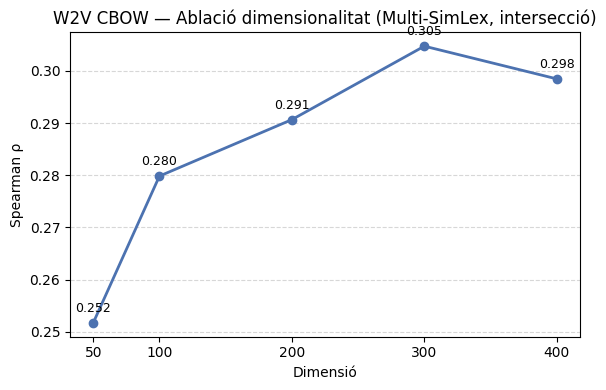

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(W2V_DIMS_LIST, abl_dim_w2v_df['spearman_rho'], marker='o', linewidth=2, color='#4C72B0')
for dim, rho in zip(W2V_DIMS_LIST, abl_dim_w2v_df['spearman_rho']):
    ax.annotate(f'{rho:.3f}', (dim, rho), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.set_xlabel('Dimensió'); ax.set_ylabel('Spearman ρ')
ax.set_title('W2V CBOW — Ablació dimensionalitat (Multi-SimLex, intersecció)')
ax.set_xticks(W2V_DIMS_LIST); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_dim_w2v.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.4 Ablació — efecte de la dimensionalitat (fastText CBOW)

Dimensions: **50, 100, 200, 300**d sobre ~50M tokens (CBOW, window=5, min_n=3, max_n=6). 
S'avalua en mode **strict** (vocab vist) sobre la intersecció de parells coberts per tots quatre models.

In [24]:
FT_DIMS_LIST = [50, 100, 200, 300]  # claus enteres de ft_models

common_dim_ft = set.intersection(
    *[get_iv_set(multisimlex_pairs, ft_models[d].wv) for d in FT_DIMS_LIST]
)
pairs_dim_ft = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_dim_ft]
print(f'Intersecció FT dim: {len(pairs_dim_ft)} / {len(multisimlex_pairs)} parells')

abl_dim_ft_rows = []
for dim in FT_DIMS_LIST:
    res = eval_model(pairs_dim_ft, ft_models[dim].wv,
                     name=f'ft-cbow-{dim}d', all_pairs=multisimlex_pairs)
    abl_dim_ft_rows.append(res)
    print(f"  ft-cbow-{dim:3d}d  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_dim_ft_df = pd.DataFrame(abl_dim_ft_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_dim_ft_df.to_string(index=False))


Intersecció FT dim: 1888 / 1888 parells
  ft-cbow- 50d  rho=0.1500  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-100d  rho=0.1703  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-200d  rho=0.1805  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d  rho=0.1876  n=1888/1888  oov_pair=0.0%  oov_word=0.0%

       model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
 ft-cbow-50d      0.150008         1888     1888             0.0             0.0
ft-cbow-100d      0.170301         1888     1888             0.0             0.0
ft-cbow-200d      0.180513         1888     1888             0.0             0.0
ft-cbow-300d      0.187610         1888     1888             0.0             0.0


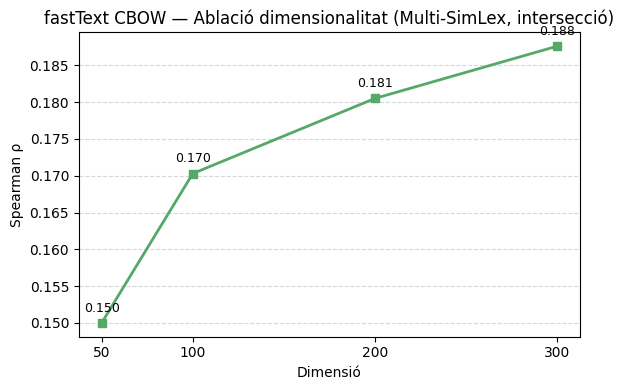

In [25]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(FT_DIMS_LIST, abl_dim_ft_df['spearman_rho'], marker='s', linewidth=2, color='#55A868')
for dim, rho in zip(FT_DIMS_LIST, abl_dim_ft_df['spearman_rho']):
    ax.annotate(f'{rho:.3f}', (dim, rho), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.set_xlabel('Dimensió'); ax.set_ylabel('Spearman ρ')
ax.set_title('fastText CBOW — Ablació dimensionalitat (Multi-SimLex, intersecció)')
ax.set_xticks(FT_DIMS_LIST); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_dim_ft.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.5 Ablació — efecte de la mida del corpus (Word2Vec CBOW, dim=300)

Corpus: **10M, 25M, 50M, all** tokens.

- **Spearman ρ** calculat sobre la intersecció de parells coberts per tots quatre models.
- **OOV stats** calculades sobre els 1.888 parells totals (cobertura real de cada model).

In [26]:
CORPUS_LABELS = ['10M', '25M', '50M', 'all']  # claus string de w2v_ablation

common_corpus_w2v = set.intersection(
    *[get_iv_set(multisimlex_pairs, w2v_ablation[lb].wv) for lb in CORPUS_LABELS]
)
pairs_corpus_w2v = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_corpus_w2v]
print(f'Intersecció W2V corpus: {len(pairs_corpus_w2v)} / {len(multisimlex_pairs)} parells')

abl_corpus_w2v_rows = []
for lb in CORPUS_LABELS:
    res = eval_model(pairs_corpus_w2v, w2v_ablation[lb].wv,
                     name=f'w2v-cbow-300d-{lb}', all_pairs=multisimlex_pairs)
    abl_corpus_w2v_rows.append(res)
    print(f"  w2v-cbow-300d-{lb:3s}  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_corpus_w2v_df = pd.DataFrame(abl_corpus_w2v_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_corpus_w2v_df.to_string(index=False))


Intersecció W2V corpus: 1184 / 1888 parells
  w2v-cbow-300d-10M  rho=0.2486  n=1184/1888  oov_pair=37.3%  oov_word=22.4%
  w2v-cbow-300d-25M  rho=0.2833  n=1184/1888  oov_pair=33.7%  oov_word=19.9%
  w2v-cbow-300d-50M  rho=0.3149  n=1184/1888  oov_pair=32.3%  oov_word=18.9%
  w2v-cbow-300d-all  rho=0.3402  n=1184/1888  oov_pair=31.5%  oov_word=18.4%

            model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
w2v-cbow-300d-10M      0.248625         1184     1888        0.372881        0.223782
w2v-cbow-300d-25M      0.283289         1184     1888        0.337394        0.198623
w2v-cbow-300d-50M      0.314940         1184     1888        0.323093        0.188824
w2v-cbow-300d-all      0.340174         1184     1888        0.314619        0.184057


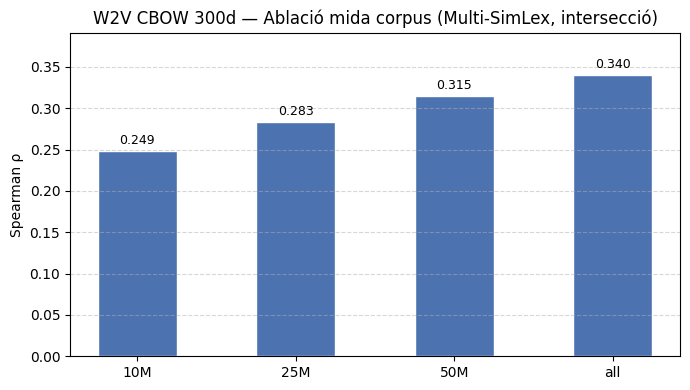

In [27]:
fig, ax = plt.subplots(figsize=(7,4))
rhos = abl_corpus_w2v_df['spearman_rho'].tolist()
x = range(len(CORPUS_LABELS))
bars = ax.bar(x, rhos, color='#4C72B0', edgecolor='white', width=0.5)
for b, v in zip(bars, rhos):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(CORPUS_LABELS)
ax.set_ylabel('Spearman ρ')
ax.set_title('W2V CBOW 300d — Ablació mida corpus (Multi-SimLex, intersecció)')
ax.set_ylim(0, max(rhos)*1.15); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_corpus_w2v.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.6 Ablació — efecte de la mida del corpus (fastText CBOW, dim=300)

Corpus: **10M, 25M, 50M, all** tokens. 

- **Spearman ρ** calculat sobre la intersecció de parells coberts per tots quatre models (mode strict, vocab vist).
- **OOV stats** calculades sobre els 1 888 parells totals (cobertura real de cada model).

In [28]:
common_corpus_ft = set.intersection(
    *[get_iv_set(multisimlex_pairs, ft_ablation[lb].wv) for lb in CORPUS_LABELS]
)
pairs_corpus_ft = [(w1,w2,s) for w1,w2,s in multisimlex_pairs if (w1,w2) in common_corpus_ft]
print(f'Intersecció FT corpus: {len(pairs_corpus_ft)} / {len(multisimlex_pairs)} parells')

abl_corpus_ft_rows = []
for lb in CORPUS_LABELS:
    res = eval_model(pairs_corpus_ft, ft_ablation[lb].wv,
                     name=f'ft-cbow-300d-{lb}', all_pairs=multisimlex_pairs)
    abl_corpus_ft_rows.append(res)
    print(f"  ft-cbow-300d-{lb:3s}  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

abl_corpus_ft_df = pd.DataFrame(abl_corpus_ft_rows)[[
    'model','spearman_rho','n_evaluated','n_total','oov_pair_ratio','oov_word_ratio']]
print()
print(abl_corpus_ft_df.to_string(index=False))


Intersecció FT corpus: 1888 / 1888 parells
  ft-cbow-300d-10M  rho=0.1298  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d-25M  rho=0.1630  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d-50M  rho=0.1876  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-cbow-300d-all  rho=0.1980  n=1888/1888  oov_pair=0.0%  oov_word=0.0%

           model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
ft-cbow-300d-10M      0.129756         1888     1888             0.0             0.0
ft-cbow-300d-25M      0.163005         1888     1888             0.0             0.0
ft-cbow-300d-50M      0.187610         1888     1888             0.0             0.0
ft-cbow-300d-all      0.198039         1888     1888             0.0             0.0


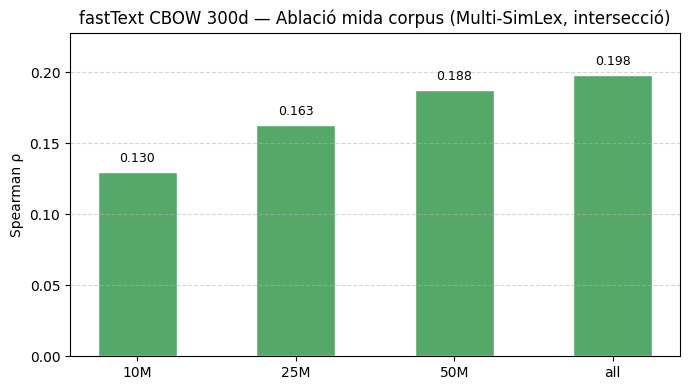

In [29]:
fig, ax = plt.subplots(figsize=(7,4))
rhos = abl_corpus_ft_df['spearman_rho'].tolist()
x = range(len(CORPUS_LABELS))
bars = ax.bar(x, rhos, color='#55A868', edgecolor='white', width=0.5)
for b, v in zip(bars, rhos):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(CORPUS_LABELS)
ax.set_ylabel('Spearman ρ')
ax.set_title('fastText CBOW 300d — Ablació mida corpus (Multi-SimLex, intersecció)')
ax.set_ylim(0, max(rhos)*1.15); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ablacio_corpus_ft.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.7 Comparativa models principals

Seleccionem la millor configuració de cada família a partir de les ablacions anteriors (corpus complet, dim=300) i les avaluem sobre tots els 1.888 parells Multi-SimLex per reflectir la cobertura real de cadascun.

| Model | Corpus | Dim | Mode |
|-------|--------|-----|------|
| `w2v-cbow-300d-all` | Wikicorpus complet | 300 | strict |
| `ft-propi-300d-all` | Wikicorpus complet | 300 | strict |
| `ft-propi-300d-all` | Wikicorpus complet | 300 | n-grams |
| `ft-oficial-300d` | Common Crawl | 300 | strict |
| `ft-oficial-300d` | Common Crawl | 300 | n-grams |

In [30]:
# W2V representatiu = corpus complet, dim=300 (w2v_ablation['all'])
models_principals = [
    ('w2v-cbow-300d-all strict', w2v_ablation['all'].wv, True),
    ('ft-propi-300d-all strict', ft_propi_strict,        True),
    ('ft-propi-300d-all ngrams', ft_propi_ngrams,        False),
    ('ft-oficial-300d strict',   ft_oficial_strict,      True),
    ('ft-oficial-300d ngrams',   ft_oficial_ngrams,      False),
]

comp_rows = []
for name, kv, strict in models_principals:
    res = eval_model(multisimlex_pairs, kv, name=name, strict=strict)
    comp_rows.append(res)
    print(f"  {name:30s}  rho={res['spearman_rho']:.4f}"
          f"  n={res['n_evaluated']}/{res['n_total']}"
          f"  oov_pair={res['oov_pair_ratio']:.1%}"
          f"  oov_word={res['oov_word_ratio']:.1%}")

simlex_df = pd.DataFrame(comp_rows)[['model', 'spearman_rho', 'n_evaluated', 'n_total',
                                      'oov_pair_ratio', 'oov_word_ratio']]
print()
print(simlex_df.to_string(index=False))


  w2v-cbow-300d-all strict        rho=0.3316  n=1294/1888  oov_pair=31.5%  oov_word=18.4%
  ft-propi-300d-all strict        rho=0.2196  n=1294/1888  oov_pair=31.5%  oov_word=18.4%
  ft-propi-300d-all ngrams        rho=0.1980  n=1888/1888  oov_pair=0.0%  oov_word=0.0%
  ft-oficial-300d strict          rho=0.5193  n=1789/1888  oov_pair=5.2%  oov_word=2.7%
  ft-oficial-300d ngrams          rho=0.5034  n=1888/1888  oov_pair=0.0%  oov_word=0.0%

                   model  spearman_rho  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
w2v-cbow-300d-all strict      0.331575         1294     1888        0.314619        0.184057
ft-propi-300d-all strict      0.219640         1294     1888        0.314619        0.184057
ft-propi-300d-all ngrams      0.198039         1888     1888        0.000000        0.000000
  ft-oficial-300d strict      0.519259         1789     1888        0.052436        0.027278
  ft-oficial-300d ngrams      0.503398         1888     1888        0.000000        0.0000

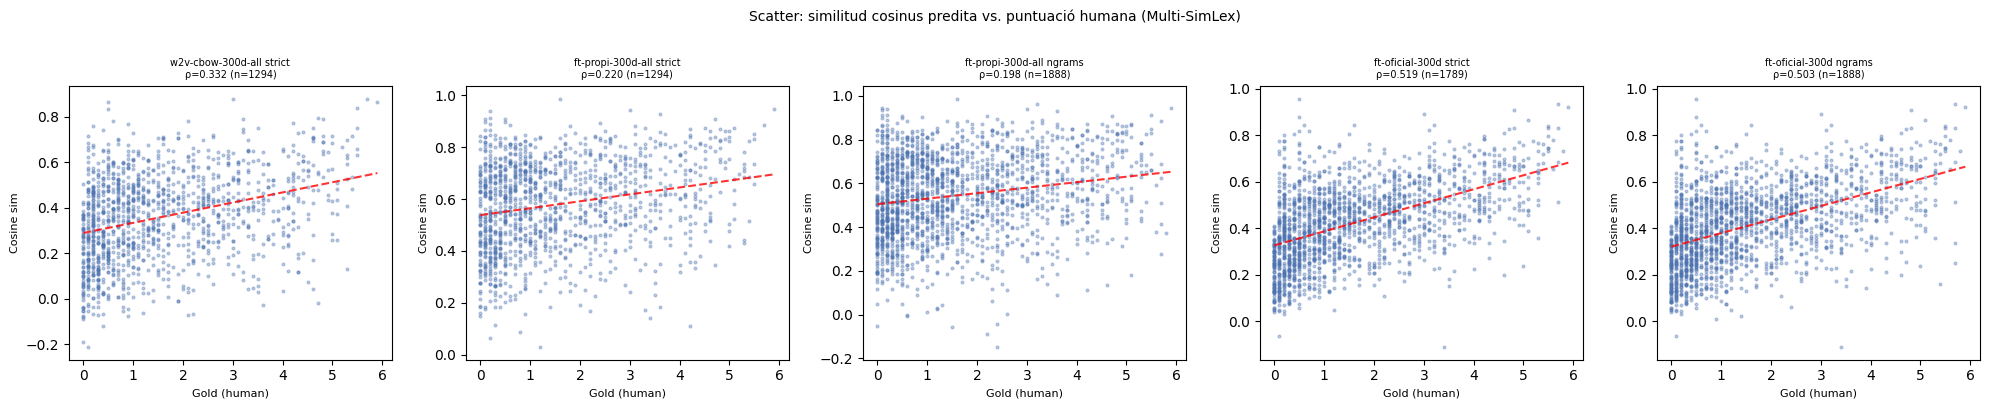

In [31]:
fig, axes = plt.subplots(1, len(models_principals), figsize=(4 * len(models_principals), 4))

for ax, (name, kv, strict) in zip(axes, models_principals):
    res = eval_model(multisimlex_pairs, kv, strict=strict)
    xs, ys = res['golds'], res['preds']
    rho = spearmanr(xs, ys).statistic if len(xs) > 2 else float('nan')
    
    ax.scatter(xs, ys, s=4, alpha=0.35, color='#4C72B0')
    
    if len(xs) > 1:
        # Línia de tendència (regressió lineal simple)
        z = np.polyfit(xs, ys, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(xs), max(xs), 100)
        ax.plot(x_trend, p(x_trend), color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(f"{name}\nρ={rho:.3f} (n={len(xs)})", fontsize=7)
    ax.set_xlabel('Gold (human)', fontsize=8)
    ax.set_ylabel('Cosine sim', fontsize=8)

plt.suptitle('Scatter: similitud cosinus predita vs. puntuació humana (Multi-SimLex)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('scatter_models_principals.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.8 Anàlisi per categoria gramatical (PoS)

Multi-SimLex distribueix els 1 888 parells en 4 categories: **nouns, verbs, adjectives, adverbs**.
Avaluem els 5 models principals per categoria.

In [32]:
from collections import defaultdict

pos_col = 'PoS'
pos_categories = sorted(multisimlex_df[pos_col].dropna().unique())

pos_pairs = defaultdict(list)
for _, row in multisimlex_df.iterrows():
    pos_pairs[row[pos_col]].append((
        str(row[W1_COL]).lower(),
        str(row[W2_COL]).lower(),
        float(row[SCORE_COL]),
    ))

model_cols = [name for name, _, _ in models_principals]
pos_rows = []
for pos in pos_categories:
    row = {'PoS': pos, 'n_parells': len(pos_pairs[pos])}
    for name, kv, strict in models_principals:
        res = eval_model(pos_pairs[pos], kv, strict=strict)
        row[name] = round(res['spearman_rho'], 4)
    pos_rows.append(row)

pos_df = pd.DataFrame(pos_rows).set_index('PoS')
print(pos_df[['n_parells'] + model_cols].to_string())


            n_parells  w2v-cbow-300d-all strict  ft-propi-300d-all strict  ft-propi-300d-all ngrams  ft-oficial-300d strict  ft-oficial-300d ngrams
PoS                                                                                                                                                
adjectives        245                    0.2571                    0.1500                    0.1451                  0.4281                  0.4006
adverbs           123                    0.4073                    0.2934                    0.2127                  0.4636                  0.3802
nouns            1051                    0.3808                    0.3129                    0.2930                  0.5851                  0.5759
verbs             469                    0.3376                    0.2953                    0.2726                  0.5144                  0.4768


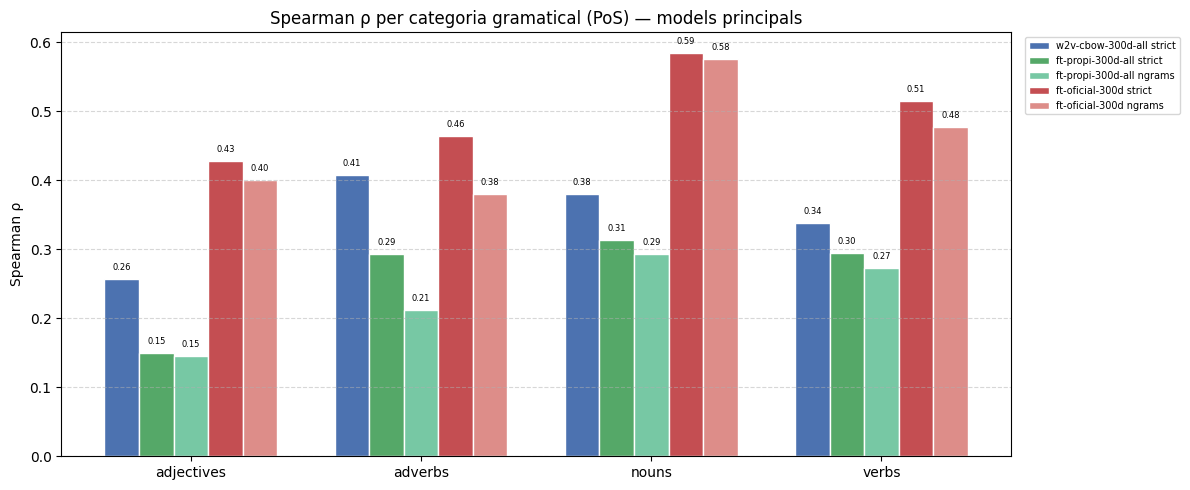

In [33]:
fig, ax = plt.subplots(figsize=(12,5))
bar_data = pos_df[model_cols]
n_pos = len(bar_data); n_mod = len(model_cols)
width = 0.15; x = np.arange(n_pos)
colors = ['#4C72B0','#55A868','#77C8A4','#C44E52','#DD8D89']

for i, (col, color) in enumerate(zip(model_cols, colors)):
    vals = bar_data[col].values.astype(float)
    rects = ax.bar(x + i*width - (n_mod-1)*width/2, vals, width,
                   label=col, color=color, edgecolor='white')
    for rect, val in zip(rects, vals):
        if not np.isnan(val):
            ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=6)

ax.set_xticks(x); ax.set_xticklabels(bar_data.index)
ax.set_ylabel('Spearman ρ')
ax.set_title('Spearman ρ per categoria gramatical (PoS) — models principals')
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pos_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.9 Anàlisi d'errors

Extraiem els 10 parells on cada model presenta el desplaçament de rang més gran entre el ranking del model (similitud cosinus) i el ranking humà (Multi-SimLex). Un error de rang elevat indica que el model ordena el parell de manera molt diferent a com ho fan els anotadors humans.

In [36]:
import pandas as pd
import numpy as np

error_analysis_dfs = {}

for name, kv, strict in models_principals:
    res = next(r for r in comp_rows if r['model'] == name)
    preds = np.array(res['preds'])
    golds = np.array(res['golds'])

    # Reconstruïm els parells de forma consistent amb evalmodel
    evaluated_pairs = []
    for w1, w2, gold in multisimlex_pairs:
        if strict and (w1 not in kv or w2 not in kv):
            continue
        try:
            _ = kv[w1]
            _ = kv[w2]
            evaluated_pairs.append((w1, w2))
        except KeyError:
            continue

    assert len(evaluated_pairs) == len(preds), \
        f"Dessincronització per {name}: {len(evaluated_pairs)} parells vs {len(preds)} preds"

    n = len(preds)

    # Rang del model (cosinus): 1 = màxima similitud predita
    rank_pred = n + 1 - preds.argsort().argsort() - 1
    # rank_pred[i] = posició de la predicció i en el ranking del model

    # Rang humà (gold): 1 = màxima similitud humana
    rank_gold = n + 1 - golds.argsort().argsort() - 1

    # Error de rang absolut
    rank_error = np.abs(rank_pred - rank_gold)

    df_errors = pd.DataFrame({
        'word1':      [p[0] for p in evaluated_pairs],
        'word2':      [p[1] for p in evaluated_pairs],
        'gold':       golds.round(3),
        'pred_cos':   preds.round(4),
        'rank_gold':  rank_gold,
        'rank_pred':  rank_pred,
        'rank_error': rank_error,
    })

    error_analysis_dfs[name] = (
        df_errors.sort_values('rank_error', ascending=False).head(10)
    )

for name, df in error_analysis_dfs.items():
    print(f"=== Pitjors parells (error de rang): {name} ===")
    display(df)
    print()

=== Pitjors parells (error de rang): w2v-cbow-300d-all strict ===


,word1,word2,gold,pred_cos,rank_gold,rank_pred,rank_error
394,marijuana,hierba,4.7,0.0174,43,1250,1207
1140,salir,entrar,0.1,0.7054,1226,40,1186
985,destruir,salvar,0.1,0.6637,1218,67,1151
887,abrazar,abrazo,4.6,0.0812,48,1181,1133
1142,recordar,olvidar,0.1,0.6387,1221,88,1133
973,aceptar,rechazar,0.2,0.7776,1139,13,1126
340,cita,compromiso,4.0,0.0329,115,1238,1123
813,aceptar,negar,0.1,0.6147,1227,110,1117
600,miembro,pierna,3.6,0.0025,146,1261,1115
764,listo,inteligente,5.3,0.1293,11,1122,1111



=== Pitjors parells (error de rang): ft-propi-300d-all strict ===


,word1,word2,gold,pred_cos,rank_gold,rank_pred,rank_error
787,feliz,contento,4.2,0.1370,84,1290,1206
1231,brillantemente,ligeramente,0.0,0.8162,1286,81,1205
1262,seguramente,pasivamente,0.0,0.8428,1231,42,1189
1265,justamente,injustamente,0.1,0.9001,1185,10,1175
1184,desorganizado,organizado,0.1,0.9096,1170,7,1163
1261,generalmente,raramente,0.1,0.8731,1183,21,1162
1260,ruidosamente,sutilmente,0.1,0.8548,1182,30,1152
813,aceptar,negar,0.1,0.8150,1227,85,1142
394,marijuana,hierba,4.7,0.3404,43,1183,1140
1142,recordar,olvidar,0.1,0.8158,1221,83,1138



=== Pitjors parells (error de rang): ft-propi-300d-all ngrams ===


,word1,word2,gold,pred_cos,rank_gold,rank_pred,rank_error
1454,escuchar,oír,5.1,0.1814,39,1836,1797
1786,herméticamente,increíblemente,0.0,0.8375,1867,75,1792
311,tifón,ciclón,4.6,0.1171,96,1865,1769
1782,brillantemente,ligeramente,0.0,0.8162,1868,115,1753
1254,nuevo,no usado,5.7,0.2702,3,1755,1752
1835,seguramente,pasivamente,0.0,0.8428,1813,64,1749
1276,feliz,contento,4.2,0.1370,150,1858,1708
1857,pacíficamente,caóticamente,0.1,0.9449,1688,4,1684
1567,cerrar,vomitar,0.0,0.7942,1850,166,1684
1839,justamente,injustamente,0.1,0.9001,1698,16,1682



=== Pitjors parells (error de rang): ft-oficial-300d strict ===


,word1,word2,gold,pred_cos,rank_gold,rank_pred,rank_error
1608,recordar,olvidar,0.1,0.7747,1687,32,1655
1606,salir,entrar,0.1,0.7320,1667,63,1604
1243,difícil,fácil,0.2,0.7767,1599,30,1569
1748,generalmente,raramente,0.1,0.7201,1641,77,1564
1426,aceptar,rechazar,0.2,0.8010,1566,22,1544
1071,artificial,0,3.4,-0.1123,254,1789,1535
150,pareja,par,4.6,0.2009,80,1610,1530
1055,fácil,difícil,0.2,0.7767,1534,29,1505
835,abundancia,mucho,5.0,0.2396,45,1532,1487
1586,reír,llorar,0.2,0.7512,1513,44,1469



=== Pitjors parells (error de rang): ft-oficial-300d ngrams ===


,word1,word2,gold,pred_cos,rank_gold,rank_pred,rank_error
1241,imprevisto,no previsible,5.4,0.1604,20,1749,1729
1680,recordar,olvidar,0.1,0.7747,1703,32,1671
1484,aceptar,rechazar,0.2,0.8010,1666,22,1644
1678,salir,entrar,0.1,0.7320,1704,63,1641
1833,generalmente,raramente,0.1,0.7201,1710,77,1633
1113,artificial,0,3.4,-0.1123,260,1888,1628
1819,cuidadosamente,de manera segura,3.9,0.1420,183,1791,1608
1096,fácil,difícil,0.2,0.7767,1631,30,1601
155,pareja,par,4.6,0.2009,94,1680,1586
1292,difícil,fácil,0.2,0.7767,1615,29,1586


## 4. Tasca 3 — Avaluació extrínseca: Spanish STS

Avaluem tres aproximacions de complexitat creixent sobre el dataset Spanish STS:

1. **Baseline cosinus** — mitjana simple i mitjana ponderada amb TF-IDF, més ablacions sobre dimensionalitat i mida del corpus.
2. **Model seqüencial siamès** — BiLSTM + Atenció amb embeddings propi (frozen, trainable) i oficial.
3. **Model BETO siamès** — encoder contextual + pooling + MLP de regressió.

Mètrica: correlació de Pearson entre prediccions i gold humà.

### 4.1 Objectiu i protocol experimental

Tots els models prediuen una puntuació de similitud entre dues frases. L'avaluació es fa amb **Pearson** contra les puntuacions humanes.

Per evitar **data leakage**: els recursos derivats d'STS (TF-IDF, vocabulari del siamès) es construeixen només amb **train**. **Dev** s'utilitza per seleccionar configuracions i fer early stopping. **Test** es reserva per a la comparació final.

### 4.2 Baseline cosinus amb embeddings estàtics

Representem cada frase com un vector agregat (mean o TF-IDF ponderat) i calculem la similitud cosinus.

#### 4.2.1 Funcions auxiliars i ajust del TF-IDF

El TF-IDF s'ajusta exclusivament amb frases de **train**.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def sentence_vector_mean(tokens, kv):
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)


def fit_tfidf(corpus_text):
    """Ajusta un TF-IDF sobre les frases d'un corpus."""
    vec = TfidfVectorizer(
        use_idf=True, smooth_idf=True, norm=None,
        tokenizer=tokenize, lowercase=False, token_pattern=None,
    )
    vec.fit(corpus_text)
    return vec


def sentence_vector_tfidf(text, tfidf, kv):
    row = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    weighted = np.zeros(kv.vector_size, dtype=np.float32)
    total_w = 0.0
    for idx, score in zip(row.indices, row.data):
        word = feature_names[idx]
        if word in kv:
            weighted += score * kv[word]
            total_w += score
    if total_w == 0:
        return sentence_vector_mean(tokenize(text), kv)
    return weighted / total_w


def evaluate_baseline(df, kv, mode="mean", tfidf=None):
    preds = []
    for s1, s2 in zip(df["sentence1"], df["sentence2"]):
        if mode == "mean":
            v1 = sentence_vector_mean(tokenize(s1), kv)
            v2 = sentence_vector_mean(tokenize(s2), kv)
        else:
            v1 = sentence_vector_tfidf(s1, tfidf, kv)
            v2 = sentence_vector_tfidf(s2, tfidf, kv)
        preds.append(cosine_sim(v1, v2))
    pearson, _ = pearsonr(preds, df["score"])
    return pearson, preds

In [ ]:
# TF-IDF ajustat només sobre train
all_train_sents = pd.concat([train_df["sentence1"], train_df["sentence2"]]).tolist()
tfidf = fit_tfidf(all_train_sents)
print(f"Vocabulari TF-IDF: {len(tfidf.get_feature_names_out())}")

Vocabulari TF-IDF: 11036


#### 4.2.2 Resultats principals — W2V propi, fastText propi i fastText oficial

In [ ]:
baselines_kvs = {
    f"w2v-{dim}d": w2v_models[dim].wv for dim in W2V_DIMS
}
baselines_kvs[f"ft-propi-{FT_DIM}d"] = ft_propi.wv
baselines_kvs["ft-oficial-300d"]    = ft_oficial_model.wv

baseline_rows = []
for name, kv in baselines_kvs.items():
    p_mean_dev,  _ = evaluate_baseline(dev_df,  kv, mode="mean")
    p_tfidf_dev, _ = evaluate_baseline(dev_df,  kv, mode="tfidf", tfidf=tfidf)
    p_mean_test, _ = evaluate_baseline(test_df, kv, mode="mean")
    p_tfidf_test,_ = evaluate_baseline(test_df, kv, mode="tfidf", tfidf=tfidf)
    baseline_rows.append({
        "model":      name,
        "mean_dev":   p_mean_dev,
        "tfidf_dev":  p_tfidf_dev,
        "mean_test":  p_mean_test,
        "tfidf_test": p_tfidf_test,
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df.style.format({c: "{:.4f}" for c in baseline_df.columns if c != "model"})
        .background_gradient(subset=["mean_test", "tfidf_test"], cmap="Greens"))

,model,mean_dev,tfidf_dev,mean_test,tfidf_test
0,w2v-50d,0.4427,0.5675,0.5317,0.5203
1,w2v-100d,0.4654,0.5933,0.5569,0.5575
2,w2v-200d,0.4872,0.6264,0.5816,0.5829
3,w2v-300d,0.4951,0.6349,0.5822,0.5877
4,w2v-400d,0.5009,0.6447,0.5915,0.5948
5,ft-propi-300d,0.5735,0.5436,0.4919,0.4957
6,ft-oficial-300d,0.4267,0.5744,0.5628,0.6523


#### 4.2.3 Efecte de la dimensionalitat a STS

Reaprofitem les dades de `baseline_df` per visualitzar el Pearson de test en funció de la dimensió del W2V.

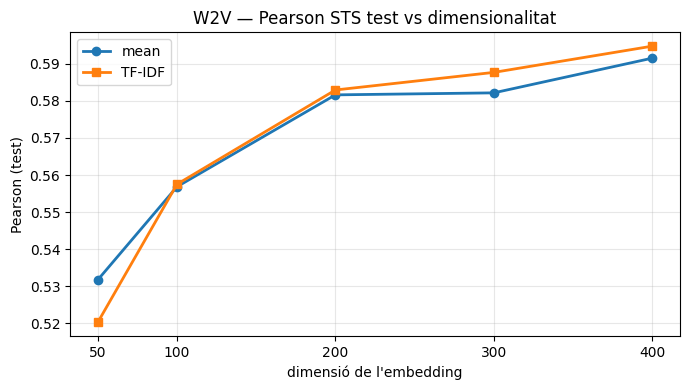

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
dims = sorted(W2V_DIMS)
w2v_rows = baseline_df[baseline_df["model"].str.startswith("w2v-")].copy()
w2v_rows["dim"] = w2v_rows["model"].str.extract(r"w2v-(\d+)d").astype(int)
w2v_rows = w2v_rows.sort_values("dim")

ax.plot(w2v_rows["dim"], w2v_rows["mean_test"],  marker="o", linewidth=2, label="mean")
ax.plot(w2v_rows["dim"], w2v_rows["tfidf_test"], marker="s", linewidth=2, label="TF-IDF")
ax.set_xlabel("dimensió de l'embedding"); ax.set_ylabel("Pearson (test)")
ax.set_title("W2V — Pearson STS test vs dimensionalitat")
ax.set_xticks(dims); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("baseline_dim_sts.png", dpi=150, bbox_inches="tight")
plt.show()

#### 4.2.4 Efecte de la mida del corpus a STS

Reavaluem els models de `w2v_ablation` i `ft_ablation` (dim=300, entrenats a §2.2 i §2.4 amb diferents mides de corpus) sobre STS. **No s'entrena res nou**: només es passa cada KV per la mateixa funció `evaluate_baseline`.

In [ ]:
corpus_results = []
for lb in ['10M', '25M', '50M', 'all']:
    for fam, kv in [("w2v", w2v_ablation[lb].wv),
                    ("ft",  ft_ablation[lb].wv)]:
        p_mean_dev,  _ = evaluate_baseline(dev_df,  kv, mode="mean")
        p_tfidf_dev, _ = evaluate_baseline(dev_df,  kv, mode="tfidf", tfidf=tfidf)
        p_mean_test, _ = evaluate_baseline(test_df, kv, mode="mean")
        p_tfidf_test,_ = evaluate_baseline(test_df, kv, mode="tfidf", tfidf=tfidf)
        corpus_results.append({
            "familia": fam, "corpus": lb,
            "mean_dev":   p_mean_dev,  "tfidf_dev":  p_tfidf_dev,
            "mean_test":  p_mean_test, "tfidf_test": p_tfidf_test,
        })
corpus_df = pd.DataFrame(corpus_results)
display(corpus_df.style.format({c: "{:.4f}" for c in corpus_df.columns if c not in ("familia","corpus")})
        .background_gradient(subset=["tfidf_test"], cmap="Greens"))

,familia,corpus,mean_dev,tfidf_dev,mean_test,tfidf_test
0,w2v,10M,0.5279,0.6051,0.5594,0.5747
1,ft,10M,0.5634,0.5575,0.5062,0.5115
2,w2v,25M,0.5011,0.6212,0.5742,0.5880
3,ft,25M,0.5736,0.5583,0.5003,0.5110
4,w2v,50M,0.4951,0.6349,0.5822,0.5877
5,ft,50M,0.5735,0.5499,0.4989,0.5046
6,w2v,all,0.4981,0.6478,0.5786,0.5770
7,ft,all,0.5735,0.5436,0.4919,0.4957


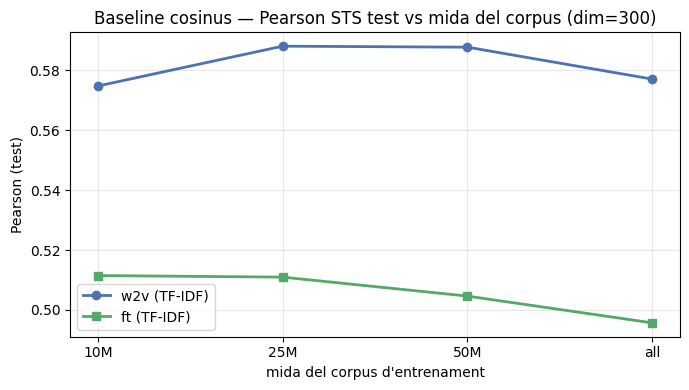

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['10M', '25M', '50M', 'all']
for fam, marker, color in [("w2v", "o", "#4C72B0"), ("ft", "s", "#55A868")]:
    sub = corpus_df[corpus_df["familia"] == fam].set_index("corpus").reindex(order)
    ax.plot(order, sub["tfidf_test"], marker=marker, linewidth=2,
            color=color, label=f"{fam} (TF-IDF)")
ax.set_xlabel("mida del corpus d'entrenament"); ax.set_ylabel("Pearson (test)")
ax.set_title("Baseline cosinus — Pearson STS test vs mida del corpus (dim=300)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("baseline_corpus_sts.png", dpi=150, bbox_inches="tight")
plt.show()

#### 4.2.5 Cobertura lèxica dels baselines sobre el vocabulari STS

Comptem, per a cada model, quantes paraules del vocabulari complet de STS (`all_words_sts`, definit a §1.2 només per inspecció) tenen vector. Una cobertura comparable entre models permet atribuir les diferències de Pearson a la qualitat dels vectors, no a la cobertura.

In [ ]:
coverage_rows = []
total = len(all_words_sts)
for name, kv in baselines_kvs.items():
    in_vocab = sum(1 for w in all_words_sts if w in kv)
    coverage_rows.append({
        "model":            name,
        "in_vocab_STS":     in_vocab,
        "total_STS":        total,
        "oov_words_ratio":  (total - in_vocab) / total,
    })
coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df.style.format({"oov_words_ratio": "{:.1%}"})
        .background_gradient(subset=["oov_words_ratio"], cmap="Reds"))

,model,in_vocab_STS,total_STS,oov_words_ratio
0,w2v-50d,8967,11904,24.7%
1,w2v-100d,8967,11904,24.7%
2,w2v-200d,8967,11904,24.7%
3,w2v-300d,8967,11904,24.7%
4,w2v-400d,8967,11904,24.7%
5,ft-propi-300d,11904,11904,0.0%
6,ft-oficial-300d,11904,11904,0.0%


### 4.3 Model seqüencial siamès amb embeddings estàtics

A diferència del baseline, el siamès no agrega manualment vectors: cada frase es codifica com una seqüència d'índexs que passa per `Embedding → BiLSTM → Atenció → MLP regressió`.

#### 4.3.1 Vocabulari, matriu d'embeddings i Dataset

El vocabulari es construeix **només amb train**. Les paraules de dev/test que no apareguin en train cauen a `<UNK>`.

In [ ]:
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1


def build_vocab_from_corpus(*dfs):
    """Construeix un vocabulari (paraula → índex) a partir de DataFrames de frases."""
    seen = set()
    for df in dfs:
        for col in ("sentence1", "sentence2"):
            for s in df[col]:
                seen.update(tokenize(s))
    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for w in sorted(seen):
        if w not in vocab:
            vocab[w] = len(vocab)
    return vocab


def build_embedding_matrix(vocab, kv, dim):
    """Inicialitza la matriu d'embeddings amb el KV. Mots desconeguts: aleatoris."""
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0, 0.1, size=(len(vocab), dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0
    found = 0
    for word, idx in vocab.items():
        if word in (PAD_TOKEN, UNK_TOKEN):
            continue
        if word in kv:
            matrix[idx] = kv[word]
            found += 1
    print(f"Cobertura: {found}/{len(vocab)-2} ({100*found/(len(vocab)-2):.1f}%)")
    return matrix


vocab_sts = build_vocab_from_corpus(train_df)
print(f"Vocabulari STS (només train): {len(vocab_sts):,}")
emb_matrix = build_embedding_matrix(vocab_sts, ft_propi.wv, FT_DIM)

Vocabulari STS (només train): 11,038
Cobertura: 11036/11036 (100.0%)


In [ ]:
class STSDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN_SEQ):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode(self, text):
        toks = tokenize(text)[: self.max_len]
        ids = [self.vocab.get(t, UNK_IDX) for t in toks]
        mask = [1] * len(ids)
        pad = self.max_len - len(ids)
        ids += [PAD_IDX] * pad
        mask += [0] * pad
        return ids, mask

    def __getitem__(self, i):
        row = self.df.iloc[i]
        ids1, m1 = self.encode(row["sentence1"])
        ids2, m2 = self.encode(row["sentence2"])
        return {
            "input_ids_1": torch.tensor(ids1, dtype=torch.long),
            "attention_mask_1": torch.tensor(m1, dtype=torch.bool),
            "input_ids_2": torch.tensor(ids2, dtype=torch.long),
            "attention_mask_2": torch.tensor(m2, dtype=torch.bool),
            "score": torch.tensor(float(row["score"]), dtype=torch.float),
        }


train_ds = STSDataset(train_df, vocab_sts)
dev_ds   = STSDataset(dev_df,   vocab_sts)
test_ds  = STSDataset(test_df,  vocab_sts)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print(f"Batches train/dev/test: {len(train_loader)}/{len(dev_loader)}/{len(test_loader)}")

Batches train/dev/test: 42/3/5


#### 4.3.2 Arquitectura siamesa

In [ ]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=64, final_hidden_size=32,
                 trainable_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=PAD_IDX,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(
            emb_dim, hidden_size, batch_first=True, bidirectional=True
        )
        self.pool = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

#### 4.3.3 Bucle d'entrenament i avaluació

La selecció del millor estat es fa amb `dev_pearson`. S'aplica `clip_grad_norm_` per estabilitzar l'entrenament.

In [ ]:
def predict_all(model, loader):
    """Retorna (preds, golds) com a llistes Python."""
    model.eval()
    preds, golds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            p = model(batch["input_ids_1"], batch["attention_mask_1"],
                      batch["input_ids_2"], batch["attention_mask_2"])
            preds.extend(p.cpu().numpy().tolist())
            golds.extend(batch["score"].cpu().numpy().tolist())
    return preds, golds


def evaluate_pearson(model, loader):
    preds, golds = predict_all(model, loader)
    return pearsonr(preds, golds)[0]


def train_regressor(model, train_loader, dev_loader, epochs, lr, name="model"):
    """
    Entrena el model i retorna (model_best, best_dev_pearson, history).
    La selecció del millor estat es fa amb dev Pearson (mai amb test).
    """
    model.to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_dev, best_state = -1.0, None
    history = {"train_loss": [], "dev_pearson": []}

    for ep in range(epochs):
        model.train()
        total = 0.0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optim.zero_grad()
            preds = model(batch["input_ids_1"], batch["attention_mask_1"],
                          batch["input_ids_2"], batch["attention_mask_2"])
            loss = loss_fn(preds, batch["score"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optim.step()
            total += loss.item()
        avg_loss = total / len(train_loader)
        dev_p = evaluate_pearson(model, dev_loader)
        history["train_loss"].append(avg_loss)
        history["dev_pearson"].append(dev_p)
        print(f"[{name}] epoch {ep+1}/{epochs}  "
              f"train_loss={avg_loss:.4f}  dev_pearson={dev_p:.4f}")
        if dev_p > best_dev:
            best_dev = dev_p
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_dev, history

#### 4.3.4 Variants amb fastText propi: frozen i trainable

In [ ]:
# Variant A: embeddings congelats
torch.manual_seed(SEED)
siamese_frozen = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=False)
siamese_frozen, dev_frozen, hist_frozen = train_regressor(
    siamese_frozen, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-propi-frozen",
)
test_frozen = evaluate_pearson(siamese_frozen, test_loader)
print(f"\n→ Pearson dev:  {dev_frozen:.4f}  |  test: {test_frozen:.4f}")

[siamese-propi-frozen] epoch 1/10  train_loss=1.6666  dev_pearson=0.0457
[siamese-propi-frozen] epoch 2/10  train_loss=1.1040  dev_pearson=0.2753
[siamese-propi-frozen] epoch 3/10  train_loss=1.0510  dev_pearson=0.3517
[siamese-propi-frozen] epoch 4/10  train_loss=0.8675  dev_pearson=0.4255
[siamese-propi-frozen] epoch 5/10  train_loss=0.6693  dev_pearson=0.4990
[siamese-propi-frozen] epoch 6/10  train_loss=0.4927  dev_pearson=0.5861
[siamese-propi-frozen] epoch 7/10  train_loss=0.3463  dev_pearson=0.5906
[siamese-propi-frozen] epoch 8/10  train_loss=0.2994  dev_pearson=0.6493
[siamese-propi-frozen] epoch 9/10  train_loss=0.2410  dev_pearson=0.6287
[siamese-propi-frozen] epoch 10/10  train_loss=0.2208  dev_pearson=0.6669

→ Pearson dev:  0.6669  |  test: 0.5626


In [ ]:
# Variant B: embeddings entrenables
torch.manual_seed(SEED)
siamese_train = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=True)
siamese_train, dev_train, hist_train = train_regressor(
    siamese_train, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-propi-trainable",
)
test_train = evaluate_pearson(siamese_train, test_loader)
print(f"\n→ Pearson dev:  {dev_train:.4f}  |  test: {test_train:.4f}")

[siamese-propi-trainable] epoch 1/10  train_loss=1.6658  dev_pearson=0.0461
[siamese-propi-trainable] epoch 2/10  train_loss=1.0988  dev_pearson=0.2750
[siamese-propi-trainable] epoch 3/10  train_loss=1.0260  dev_pearson=0.3405
[siamese-propi-trainable] epoch 4/10  train_loss=0.7767  dev_pearson=0.4019
[siamese-propi-trainable] epoch 5/10  train_loss=0.6352  dev_pearson=0.4809
[siamese-propi-trainable] epoch 6/10  train_loss=0.4156  dev_pearson=0.5590
[siamese-propi-trainable] epoch 7/10  train_loss=0.2867  dev_pearson=0.5333
[siamese-propi-trainable] epoch 8/10  train_loss=0.2470  dev_pearson=0.5778
[siamese-propi-trainable] epoch 9/10  train_loss=0.2008  dev_pearson=0.6221
[siamese-propi-trainable] epoch 10/10  train_loss=0.2166  dev_pearson=0.6123

→ Pearson dev:  0.6221  |  test: 0.5843


#### 4.3.5 Variant amb fastText oficial

Aïllem l'efecte de la qualitat dels embeddings a nivell seqüencial: mateixa arquitectura, només canvia la matriu d'inicialització. Comparem frozen i trainable per veure si descongelar uns embeddings entrenats sobre Common Crawl (~2B tokens) els degrada sobre un dataset petit com STS train (~5k parells).

In [ ]:
# Matriu d'embeddings amb fastText oficial (300d) sobre el mateix vocab_sts
emb_matrix_oficial = build_embedding_matrix(vocab_sts, ft_oficial_model.wv, 300)

torch.manual_seed(SEED)
siamese_oficial = SiameseBiLSTMAttention(emb_matrix_oficial, trainable_embeddings=False)
siamese_oficial, dev_oficial, hist_oficial = train_regressor(
    siamese_oficial, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-oficial-frozen",
)
test_oficial = evaluate_pearson(siamese_oficial, test_loader)
print(f"\n→ Pearson dev:  {dev_oficial:.4f}  |  test: {test_oficial:.4f}")

Cobertura: 11036/11036 (100.0%)
[siamese-oficial-frozen] epoch 1/10  train_loss=2.3060  dev_pearson=0.0416
[siamese-oficial-frozen] epoch 2/10  train_loss=1.1740  dev_pearson=0.2586
[siamese-oficial-frozen] epoch 3/10  train_loss=1.1503  dev_pearson=0.3544
[siamese-oficial-frozen] epoch 4/10  train_loss=1.0387  dev_pearson=0.4398
[siamese-oficial-frozen] epoch 5/10  train_loss=0.9971  dev_pearson=0.4557
[siamese-oficial-frozen] epoch 6/10  train_loss=0.9552  dev_pearson=0.5069
[siamese-oficial-frozen] epoch 7/10  train_loss=0.9200  dev_pearson=0.4735
[siamese-oficial-frozen] epoch 8/10  train_loss=0.9002  dev_pearson=0.4725
[siamese-oficial-frozen] epoch 9/10  train_loss=0.8834  dev_pearson=0.5055
[siamese-oficial-frozen] epoch 10/10  train_loss=0.8203  dev_pearson=0.5216

→ Pearson dev:  0.5216  |  test: 0.4586


In [ ]:
# Variant ft-oficial trainable (fine-tuning de la matriu)
torch.manual_seed(SEED)
siamese_oficial_train = SiameseBiLSTMAttention(emb_matrix_oficial, trainable_embeddings=True)
siamese_oficial_train, dev_oficial_train, hist_oficial_train = train_regressor(
    siamese_oficial_train, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-oficial-trainable",
)
test_oficial_train = evaluate_pearson(siamese_oficial_train, test_loader)
print(f"\n→ Pearson dev:  {dev_oficial_train:.4f}  |  test: {test_oficial_train:.4f}")

[siamese-oficial-trainable] epoch 1/10  train_loss=2.2696  dev_pearson=0.0734
[siamese-oficial-trainable] epoch 2/10  train_loss=1.1026  dev_pearson=0.2884
[siamese-oficial-trainable] epoch 3/10  train_loss=0.7536  dev_pearson=0.2165
[siamese-oficial-trainable] epoch 4/10  train_loss=0.4426  dev_pearson=0.1790
[siamese-oficial-trainable] epoch 5/10  train_loss=0.3452  dev_pearson=0.1759
[siamese-oficial-trainable] epoch 6/10  train_loss=0.2665  dev_pearson=0.1955
[siamese-oficial-trainable] epoch 7/10  train_loss=0.2337  dev_pearson=0.2215
[siamese-oficial-trainable] epoch 8/10  train_loss=0.2309  dev_pearson=0.1837
[siamese-oficial-trainable] epoch 9/10  train_loss=0.2138  dev_pearson=0.2101
[siamese-oficial-trainable] epoch 10/10  train_loss=0.2003  dev_pearson=0.1832

→ Pearson dev:  0.2884  |  test: 0.3333


#### 4.3.6 Corbes d'entrenament

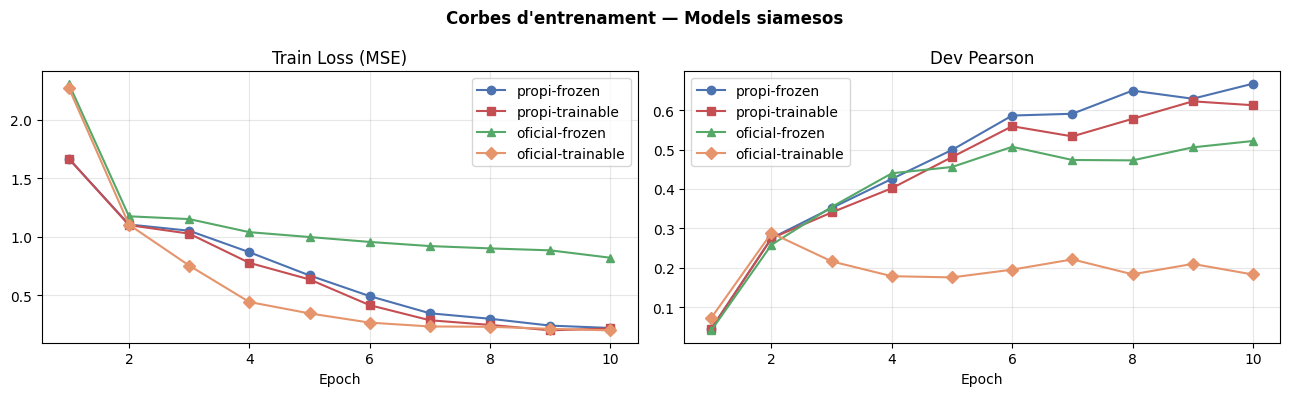

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, SIAMESE_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Corbes d'entrenament — Models siamesos", fontweight="bold")

styles = [
    ("propi-frozen",      hist_frozen,         "o", "#4C72B0"),
    ("propi-trainable",   hist_train,          "s", "#C44E52"),
    ("oficial-frozen",    hist_oficial,        "^", "#55A868"),
    ("oficial-trainable", hist_oficial_train,  "D", "#E5946C"),
]
for name, h, m, c in styles:
    ax1.plot(epochs_range, h["train_loss"],  marker=m, label=name, color=c)
    ax2.plot(epochs_range, h["dev_pearson"], marker=m, label=name, color=c)

ax1.set_title("Train Loss (MSE)"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_title("Dev Pearson"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("siamese_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

#### 4.3.7 Resum del bloc seqüencial

In [ ]:
sequential_summary = pd.DataFrame([
    {"model": "Siamese BiLSTM+Att", "embeddings": "fastText propi (300d)",
     "trainable": False, "dev_pearson": dev_frozen,         "test_pearson": test_frozen},
    {"model": "Siamese BiLSTM+Att", "embeddings": "fastText propi (300d)",
     "trainable": True,  "dev_pearson": dev_train,          "test_pearson": test_train},
    {"model": "Siamese BiLSTM+Att", "embeddings": "fastText oficial (300d)",
     "trainable": False, "dev_pearson": dev_oficial,        "test_pearson": test_oficial},
    {"model": "Siamese BiLSTM+Att", "embeddings": "fastText oficial (300d)",
     "trainable": True,  "dev_pearson": dev_oficial_train,  "test_pearson": test_oficial_train},
])
display(sequential_summary.style.format({"dev_pearson": "{:.4f}", "test_pearson": "{:.4f}"})
        .background_gradient(subset=["dev_pearson", "test_pearson"], cmap="Greens"))

,model,embeddings,trainable,dev_pearson,test_pearson
0,Siamese BiLSTM+Att,fastText propi (300d),False,0.6669,0.5626
1,Siamese BiLSTM+Att,fastText propi (300d),True,0.6221,0.5843
2,Siamese BiLSTM+Att,fastText oficial (300d),False,0.5216,0.4586
3,Siamese BiLSTM+Att,fastText oficial (300d),True,0.2884,0.3333


### 4.4 Model BERT/BETO siamès

BETO (`dccuchile/bert-base-spanish-wwm-cased`) genera representacions contextuals: una paraula pot tenir vectors diferents segons la frase. Cada frase es passa per BETO, es fa mean pooling sobre la màscara d'atenció, i una MLP de regressió prediu el score.

In [ ]:
from transformers import AutoTokenizer, AutoModel

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


class STSBertDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN_SEQ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        e1 = self.tokenizer(row["sentence1"], truncation=True,
                            padding="max_length", max_length=self.max_len,
                            return_tensors="pt")
        e2 = self.tokenizer(row["sentence2"], truncation=True,
                            padding="max_length", max_length=self.max_len,
                            return_tensors="pt")
        return {
            "input_ids_1": e1["input_ids"].squeeze(0),
            "attention_mask_1": e1["attention_mask"].squeeze(0),
            "input_ids_2": e2["input_ids"].squeeze(0),
            "attention_mask_2": e2["attention_mask"].squeeze(0),
            "score": torch.tensor(float(row["score"]), dtype=torch.float),
        }


bert_train = DataLoader(STSBertDataset(train_df, bert_tokenizer), batch_size=16, shuffle=True)
bert_dev   = DataLoader(STSBertDataset(dev_df,   bert_tokenizer), batch_size=16)
bert_test  = DataLoader(STSBertDataset(test_df,  bert_tokenizer), batch_size=16)

In [ ]:
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name=BERT_MODEL_NAME, final_hidden_size=128):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.pool = MeanPooling()
        hidden = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

In [ ]:
torch.manual_seed(SEED)
beto_model = BETOSiameseRegressor()
beto_model, dev_bert, hist_bert = train_regressor(
    beto_model, bert_train, bert_dev,
    epochs=BERT_EPOCHS, lr=BERT_LR, name="beto-siamese",
)
test_bert = evaluate_pearson(beto_model, bert_test)
print(f"\n→ Pearson dev:  {dev_bert:.4f}  |  test: {test_bert:.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[beto-siamese] epoch 1/16  train_loss=1.2854  dev_pearson=0.3081
[beto-siamese] epoch 2/16  train_loss=0.8311  dev_pearson=0.5762
[beto-siamese] epoch 3/16  train_loss=0.4798  dev_pearson=0.7138
[beto-siamese] epoch 4/16  train_loss=0.2466  dev_pearson=0.7313
[beto-siamese] epoch 5/16  train_loss=0.1887  dev_pearson=0.7463
[beto-siamese] epoch 6/16  train_loss=0.1505  dev_pearson=0.7339
[beto-siamese] epoch 7/16  train_loss=0.1289  dev_pearson=0.7713
[beto-siamese] epoch 8/16  train_loss=0.1173  dev_pearson=0.7467
[beto-siamese] epoch 9/16  train_loss=0.1104  dev_pearson=0.7423
[beto-siamese] epoch 10/16  train_loss=0.0998  dev_pearson=0.7685
[beto-siamese] epoch 11/16  train_loss=0.0949  dev_pearson=0.7610
[beto-siamese] epoch 12/16  train_loss=0.0882  dev_pearson=0.7326
[beto-siamese] epoch 13/16  train_loss=0.0857  dev_pearson=0.7673
[beto-siamese] epoch 14/16  train_loss=0.0860  dev_pearson=0.7526
[beto-siamese] epoch 15/16  train_loss=0.0714  dev_pearson=0.7673
[beto-siamese] epoc

#### 4.4.1 Corbes d'entrenament — BETO

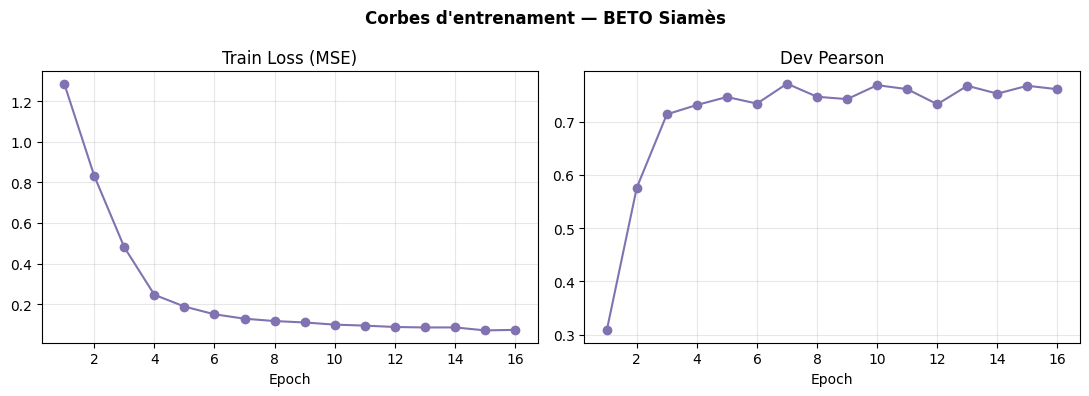

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Corbes d'entrenament — BETO Siamès", fontweight="bold")
epochs_bert = range(1, BERT_EPOCHS + 1)
ax1.plot(epochs_bert, hist_bert["train_loss"],  marker="o", color="#8172B2")
ax1.set_title("Train Loss (MSE)"); ax1.set_xlabel("Epoch"); ax1.grid(alpha=0.3)
ax2.plot(epochs_bert, hist_bert["dev_pearson"], marker="o", color="#8172B2")
ax2.set_title("Dev Pearson"); ax2.set_xlabel("Epoch"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("beto_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Comparació global i guanys

Consolidem totes les configuracions sota la mateixa mètrica (Pearson sobre Spanish STS) i quantifiquem els guanys de cada salt arquitectural.

#### 4.5.1 Taula i gràfic comparatius

,familia,model,configuracio,dev_pearson,test_pearson
0,BETO siamès,beto-siamese,fine-tune,0.7713,0.7315
1,Baseline FT oficial,ft-oficial-300d,tfidf,0.5744,0.6523
2,Baseline W2V propi,w2v-400d,tfidf,0.6447,0.5948
3,Baseline W2V propi,w2v-400d,mean,0.5009,0.5915
4,Baseline W2V propi,w2v-300d,tfidf,0.6349,0.5877
5,Siamese BiLSTM (propi),siamese-propi-trainable,trainable,0.6221,0.5843
6,Baseline W2V propi,w2v-200d,tfidf,0.6264,0.5829
7,Baseline W2V propi,w2v-300d,mean,0.4951,0.5822
8,Baseline W2V propi,w2v-200d,mean,0.4872,0.5816
9,Baseline FT oficial,ft-oficial-300d,mean,0.4267,0.5628


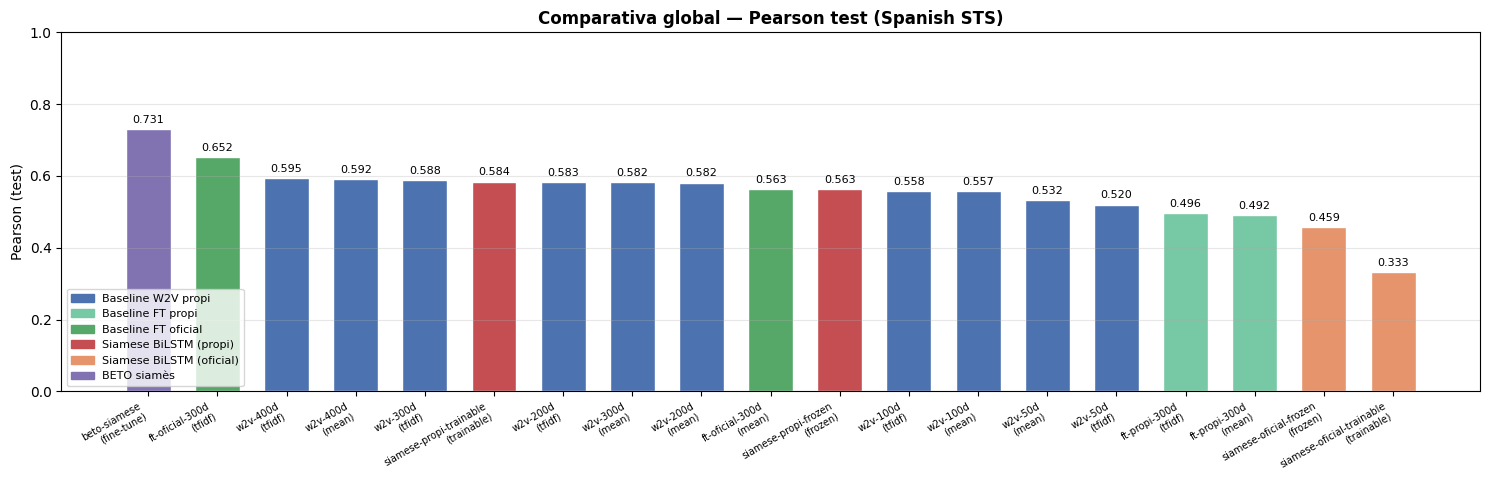

In [ ]:
import matplotlib.patches as mpatches

comparison_rows = []
# Baselines (W2V propi, FT propi, FT oficial) × {mean, tfidf}
for _, row in baseline_df.iterrows():
    fam = ("Baseline W2V propi"   if row["model"].startswith("w2v")
           else "Baseline FT propi" if "ft-propi" in row["model"]
           else "Baseline FT oficial")
    for cfg, dev_k, test_k in [("mean",  "mean_dev",  "mean_test"),
                                ("tfidf", "tfidf_dev", "tfidf_test")]:
        comparison_rows.append({
            "familia": fam, "model": row["model"], "configuracio": cfg,
            "dev_pearson": row[dev_k], "test_pearson": row[test_k],
        })

# Models neurals
comparison_rows += [
    {"familia": "Siamese BiLSTM (propi)",   "model": "siamese-propi-frozen",
     "configuracio": "frozen",    "dev_pearson": dev_frozen,        "test_pearson": test_frozen},
    {"familia": "Siamese BiLSTM (propi)",   "model": "siamese-propi-trainable",
     "configuracio": "trainable", "dev_pearson": dev_train,         "test_pearson": test_train},
    {"familia": "Siamese BiLSTM (oficial)", "model": "siamese-oficial-frozen",
     "configuracio": "frozen",    "dev_pearson": dev_oficial,       "test_pearson": test_oficial},
    {"familia": "Siamese BiLSTM (oficial)", "model": "siamese-oficial-trainable",
     "configuracio": "trainable", "dev_pearson": dev_oficial_train, "test_pearson": test_oficial_train},
    {"familia": "BETO siamès",              "model": "beto-siamese",
     "configuracio": "fine-tune", "dev_pearson": dev_bert,          "test_pearson": test_bert},
]

comp_df = (pd.DataFrame(comparison_rows)
             .sort_values("test_pearson", ascending=False)
             .reset_index(drop=True))

display(comp_df.style.format({"dev_pearson": "{:.4f}", "test_pearson": "{:.4f}"})
        .background_gradient(subset=["test_pearson"], cmap="Greens"))

# Gràfic
color_map = {
    "Baseline W2V propi":      "#4C72B0",
    "Baseline FT propi":       "#77C8A4",
    "Baseline FT oficial":     "#55A868",
    "Siamese BiLSTM (propi)":  "#C44E52",
    "Siamese BiLSTM (oficial)":"#E5946C",
    "BETO siamès":             "#8172B2",
}
bar_labels = [f"{r['model']}\n({r['configuracio']})" for _, r in comp_df.iterrows()]
bar_colors = [color_map[r["familia"]] for _, r in comp_df.iterrows()]

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(bar_labels, comp_df["test_pearson"], color=bar_colors, edgecolor="white", width=0.65)
ax.set_ylabel("Pearson (test)"); ax.set_ylim(0, 1)
ax.set_title("Comparativa global — Pearson test (Spanish STS)", fontweight="bold")
ax.bar_label(bars, fmt="{:.3f}", fontsize=8, padding=3)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", labelsize=7, rotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.legend(handles=[mpatches.Patch(color=v, label=k) for k, v in color_map.items()],
          loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig("comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

#### 4.5.2 Guanys explícits

Quantifiquem els dos guanys arquitecturals que demana l'enunciat. Per evitar barrejar l'efecte de l'embedding amb el de l'arquitectura, el primer guany compara la mateixa família d'embeddings (fastText propi). Selecció **per dev**.

In [ ]:
# Millor baseline ft-propi per dev
ft_propi_rows = comp_df[comp_df["model"] == f"ft-propi-{FT_DIM}d"]
best_ft_baseline = ft_propi_rows.loc[ft_propi_rows["dev_pearson"].idxmax()]

# Millor siamès (qualsevol família d'embeddings) per dev
siamese_rows = comp_df[comp_df["familia"].str.startswith("Siamese")]
best_siamese  = siamese_rows.loc[siamese_rows["dev_pearson"].idxmax()]

gains = pd.DataFrame([
    {"comparació": "Baseline FT propi → Siamès (millor per dev)",
     "model_A": best_ft_baseline["model"] + " " + best_ft_baseline["configuracio"],
     "test_A":  best_ft_baseline["test_pearson"],
     "model_B": best_siamese["model"],
     "test_B":  best_siamese["test_pearson"],
     "guany":   best_siamese["test_pearson"] - best_ft_baseline["test_pearson"]},
    {"comparació": "Siamès estàtic → BETO contextual",
     "model_A": best_siamese["model"],
     "test_A":  best_siamese["test_pearson"],
     "model_B": "beto-siamese",
     "test_B":  test_bert,
     "guany":   test_bert - best_siamese["test_pearson"]},
])
display(gains.style.format({"test_A": "{:.4f}", "test_B": "{:.4f}", "guany": "{:+.4f}"})
        .background_gradient(subset=["guany"], cmap="RdYlGn"))

,comparació,model_A,test_A,model_B,test_B,guany
0,Baseline FT propi → Siamès (millor per dev),ft-propi-300d mean,0.4919,siamese-propi-frozen,0.5626,+0.0707
1,Siamès estàtic → BETO contextual,siamese-propi-frozen,0.5626,beto-siamese,0.7315,+0.1689


### 4.6 Anàlisi d'errors per família

Per a cada família, seleccionem el model **guanyador per dev** i mostrem els top-10 errors absoluts sobre test. La selecció per dev evita que la mostra d'errors estigui esbiaixada per la informació del test.

#### 4.6.1 Errors top-10 — millor baseline cosinus

In [ ]:
# Selecció del millor baseline per dev (entre totes les configuracions baseline)
baseline_rows_comp = comp_df[comp_df["familia"].str.startswith("Baseline")]
best_baseline_row = baseline_rows_comp.loc[baseline_rows_comp["dev_pearson"].idxmax()]
print(f"Millor baseline per dev: {best_baseline_row['model']} ({best_baseline_row['configuracio']})  "
      f"dev={best_baseline_row['dev_pearson']:.4f}  test={best_baseline_row['test_pearson']:.4f}")

# Recuperar les prediccions de test del baseline guanyador
kv_winner   = baselines_kvs[best_baseline_row["model"]]
mode_winner = best_baseline_row["configuracio"]
_, preds_baseline = evaluate_baseline(test_df, kv_winner, mode=mode_winner, tfidf=tfidf)

errors_baseline = pd.DataFrame({
    "sentence1": test_df["sentence1"].values,
    "sentence2": test_df["sentence2"].values,
    "gold":      test_df["score"].values,
    "pred":      preds_baseline,
})
errors_baseline["abs_err"] = (errors_baseline["gold"] - errors_baseline["pred"]).abs()
errors_baseline = errors_baseline.sort_values("abs_err", ascending=False).reset_index(drop=True)

display(errors_baseline[["gold", "pred", "abs_err", "sentence1", "sentence2"]].head(10)
        .style.format({"gold": "{:.2f}", "pred": "{:.2f}", "abs_err": "{:.2f}"})
        .background_gradient(subset="abs_err", cmap="Reds"))

Millor baseline per dev: w2v-400d (tfidf)  dev=0.6447  test=0.5948


,gold,pred,abs_err,sentence1,sentence2
0,4.00,0.90,3.10,"Un joven marsellés fue condenado hoy a un año de prisión por haber maltratado a un gato, filmado la escena y colgado la grabación en internet.","París - Un joven ha sido condenado a un año de cárcel por haber maltratado un gato, grabado la escena y subido el video a Internet."
1,4.00,0.95,3.05,"El ministro ruso de Finanzas, Anton Siluanov, anunció ayer que el Kremlin no reanudará el rescate de la economía ucraniana hasta que Kiev salde sus deudas por el suministro de gas natural en 2013.","El ministro ruso de Finanzas, Antón Siluánov , aseguró el sábado que Moscú reanudará el rescate a la economía de Ucrania cuando este país salde sus deudas por el suministro de gas natural en 2013."
2,4.00,0.96,3.04,"Antes de ese evento, el presidente uruguayo ya había adelantado su intención de aprovechar su viaje a Cuba para mantener contactos tanto con representantes de la guerrilla como con Juan Manuel Santos, que también participó en la cumbre, pero quien finalmente no se reunió con Mujica.","Antes del encuentro, el presidente uruguayo había adelantado su intención de aprovechar la cita para mantener contactos tanto con representantes de la guerrilla como con su homólogo colombiano, Juan Manuel Santos, que también participó en la cumbre pero que finalmente no se reunió con Mujica."
3,4.00,0.98,3.02,"El nivel de las aguas del río Támesis está en su nivel más alto desde la década de 1980 debido a la intensidad de las lluvias de las últimas semanas en Inglaterra, informó este lunes la Agencia medioambiental británica.","El nivel de las aguas del río Támesis está en su nivel más alto desde los pasados años ochenta debido a la intensidad de las lluvias de las últimas semanas en Inglaterra, informó este lunes la Agencia medioambiental británica."
4,3.80,0.83,2.97,"Estados Unidos informó este domingo que Corea del Norte retiró la invitación para que un enviado especial visitara Pyongyang, con el objetivo de negociar la liberación de Kenneth Bae, el ciudadano estadounidense condenado a 15 años de trabajo forzado.","Corea del Norte canceló este domingo su invitación para que el enviado de Washington Robert King visitase Pyongyang con el fin de hablar sobre el ciudadano estadounidense Kenneth Bae, preso en el país desde 2012, informó el Departamento de Estado a la cadena CNN."
5,3.60,0.64,2.96,"El presidente de Estados Unidos, Barack Obama, anunciará la próxima semana un amplio paquete de medidas ejecutivas en política migratoria con las que pretende evitar la deportación de más de cinco millones de personas, informó el diario ""The New York Times"".","El presidente de EE.UU., Barack Obama, anunciará la próxima semana su prometido paquete de medidas ejecutivas sobre inmigración, que incluirá la suspensión de millones de deportaciones, según una información de la cadena FOX que cita fuentes cercanas a la Casa Blanca."
6,3.80,0.85,2.95,El legado de Mandela incluye también una poderosa marca política y moral que algunos de sus nietos y bisnietos ya han utilizado para comercializar desde ropa hasta un reality de televisión.,"De forma más visible, su legado incluye una marca política y moral con enorme potencial que algunos de sus nietos y bisnietos ya han aprovechado para vender todo tipo de cosas, desde ropas hasta 'realities' en televisión."
7,3.80,0.89,2.91,"El profesor universitario y candidato del PAC, Luis Guillermo Solís, al que las encuestas situaban en cuarto lugar, se enfrentará el próximo 6 de abril a Johnny Araya, alcalde de San José durante 21 años y candidato del PLN, partido de corte socialdemócrata liderado tradicionalmente por el Premio Nobel de la Paz y expresidente Oscar Arias.","El profesor universitario y candidato del PAC, Luis Guillermo Solís, al que las encuestas situaban en cuarto lugar, se enfrentará a Johnny Araya, alcalde de San José durante 21 años y sucesor en el partido oficialista de la saliente Laura Chinchilla, la gobernante más impopular de la historia reciente

#### 4.6.2 Errors top-10 — millor siamès

In [ ]:
# Selecció del millor siamès per dev
print(f"Millor siamès per dev: {best_siamese['model']}  "
      f"dev={best_siamese['dev_pearson']:.4f}  test={best_siamese['test_pearson']:.4f}")

siamese_models_dict = {
    "siamese-propi-frozen":      siamese_frozen,
    "siamese-propi-trainable":   siamese_train,
    "siamese-oficial-frozen":    siamese_oficial,
    "siamese-oficial-trainable": siamese_oficial_train,
}
winner_siamese = siamese_models_dict[best_siamese["model"]]

preds_siam, golds_siam = predict_all(winner_siamese, test_loader)

errors_siamese = pd.DataFrame({
    "sentence1": test_df["sentence1"].values,
    "sentence2": test_df["sentence2"].values,
    "gold":      golds_siam,
    "pred":      preds_siam,
})
errors_siamese["abs_err"] = (errors_siamese["gold"] - errors_siamese["pred"]).abs()
errors_siamese = errors_siamese.sort_values("abs_err", ascending=False).reset_index(drop=True)

display(errors_siamese[["gold", "pred", "abs_err", "sentence1", "sentence2"]].head(10)
        .style.format({"gold": "{:.2f}", "pred": "{:.2f}", "abs_err": "{:.2f}"})
        .background_gradient(subset="abs_err", cmap="Reds"))

Millor siamès per dev: siamese-propi-frozen  dev=0.6669  test=0.5626


,gold,pred,abs_err,sentence1,sentence2
0,3.20,0.89,2.31,"La ""heráldica"" es la ciencia del blasón («blasón», según la RAE se define como el «arte de explicar y describir los escudos de armas de cada linaje, ciudad o persona»).","La heráldica es esencialmente la ciencia de los heraldos, y su origen no puede comprenderse sino a través de su rol."
1,2.80,0.63,2.17,"El precio posteriormente será de 9,99 dólares mensuales, abono que también permitirá el acceso al servicio de música ""streaming"" de Google, con más de 30 millones de canciones.","Los suscriptores de Music Key tendrán acceso gratuito al ""streaming"" de las 30 millones de canciones presentes en la tienda Google Play."
2,3.40,1.27,2.13,"Venus es normalmente conocido como la estrella de la mañana (""Lucero del Alba"") o la estrella de la tarde (""Lucero Vespertino"") y, cuando es visible en el cielo nocturno, es el segundo objeto más brillante del firmamento, tras la Luna.","Venus es el astro más característico en los cielos de la mañana y de la tarde de la Tierra (después del Sol y la Luna), y es conocido por el hombre desde la prehistoria."
3,2.80,0.74,2.06,"Sicarios han declarado que asesinaron a los muchachos e incineraron sus cuerpos durante 14 horas en un basurero de la localidad de Cocula, vecina de Iguala, y después arrojaron los restos en bolsas a un río.",Los sicarios detenidos dijeron que en ese basurero quemaron los cuerpos de los estudiantes y que luego arrojaron sus restos al río.
4,2.60,0.56,2.04,"En sus apariciones se presenta como un hombre interesado por los negocios tras conseguir la cabeza de Chiriku, por la cual quiere cobrar una recompensa.","Desde sus primeras apariciones, Kakuzu demuestra ser una persona fría y muy interesada por los negocios, como lo demuestra al entregar la cabeza de Chiriku (amigo de Asuma que protegió al Señor Feudal del Fuego)."
5,4.00,2.00,2.00,"El ministro ruso de Finanzas, Anton Siluanov, anunció ayer que el Kremlin no reanudará el rescate de la economía ucraniana hasta que Kiev salde sus deudas por el suministro de gas natural en 2013.","El ministro ruso de Finanzas, Antón Siluánov , aseguró el sábado que Moscú reanudará el rescate a la economía de Ucrania cuando este país salde sus deudas por el suministro de gas natural en 2013."
6,3.40,1.41,1.99,"La ""heráldica"" es la ciencia del blasón («blasón», según la RAE se define como el «arte de explicar y describir los escudos de armas de cada linaje, ciudad o persona»).","La heráldica es lo relativo al lenguaje del blasón, a la ciencia de los heraldos y al diseño de las armerías."
7,2.80,0.87,1.93,"El ""tendón de Aquiles"" (""tendo Achillis"") o ""tendón calcáneo"" (""tendo calcaneus"") es un tendón de la parte posterior de la pierna.","El tendón de Aquiles es la extensión tendinosa de los tres músculos de la pantorrilla: gemelo, sóleo y plantar delgado."
8,3.40,1.66,1.74,"""Izamal"" (en idioma maya, Itzmal: rocío del cielo) es una ciudad mexicana, cabecera del municipio del mismo nombre (uno de los 106 que conforman la entidad federativa) en el Estado de Yucatán.","El municipio de Izamal es uno de los 106 municipos del Estado de Yucatán, México ubicado en la parte central hacia el norte de la península de Yucatán."
9,2.80,1.13,1.67,"El ""Bosque de Boulogne"" (en francés: ""Bois de Boulogne"") o de Bolonia, es un parque que se encuentra en el límite oeste del XVI distrito o arrondissement de París, cerca del suburbio de Boulogne-Billancourt.","El ""Bosque de Boulogne"" fue oficialmente anexionado a la ciudad de París en 1929 y fue incorporado al XVI arrondissement."


#### 4.6.3 Errors top-10 — BETO siamès

In [ ]:
preds_bert, golds_bert = predict_all(beto_model, bert_test)
errors_bert = pd.DataFrame({
    "sentence1": test_df["sentence1"].values,
    "sentence2": test_df["sentence2"].values,
    "gold":      golds_bert,
    "pred":      preds_bert,
})
errors_bert["abs_err"] = (errors_bert["gold"] - errors_bert["pred"]).abs()
errors_bert = errors_bert.sort_values("abs_err", ascending=False).reset_index(drop=True)

display(errors_bert[["gold", "pred", "abs_err", "sentence1", "sentence2"]].head(10)
        .style.format({"gold": "{:.2f}", "pred": "{:.2f}", "abs_err": "{:.2f}"})
        .background_gradient(subset="abs_err", cmap="Reds"))

,gold,pred,abs_err,sentence1,sentence2
0,0.80,2.48,1.68,"El drama se desarrolló a la altura de la planta 69 del edificio, también conocido como ""Torre de la Libertad"", que ocupa parte del espacio que dejaron las Torres Gemelas, destruidas por los atentados terroristas del 11 de septiembre de 2001.","Aparentemente el cable se desató mientras uno de trabajadores subía a la cima de la torre, la más alta de Estados Unidos."
1,0.60,2.27,1.67,"El Gobierno solicitará 5.600 millones de dólares al Congreso para las operaciones en Irak y Siria, que incluirán 1.600 millones de dólares para el nuevo ""Fondo de Entrenamiento y Equipamiento en Irak"", explicó la Oficina de gestión y Presupuesto de la Casa Blanca.","En junio, el gobierno pidió 58,600 millones de dólares para el presupuesto de operaciones de guerra del año fiscal en curso, que comenzó el 1 de octubre."
2,1.00,2.55,1.55,"El misterioso magnate hizo la oferta hace unos meses, pero Mujica lo dijo ahora porque el embajador de México en Uruguay, Felipe Enríquez, le manifestó al presidente su deseo de adquirir el automóvil.","“Ya tengo un arreglo de palabra con un árabe”, dijo entonces Mujica, con lo cual el trato se hizo de conocimiento público."
3,3.80,2.27,1.53,El legado de Mandela incluye también una poderosa marca política y moral que algunos de sus nietos y bisnietos ya han utilizado para comercializar desde ropa hasta un reality de televisión.,"De forma más visible, su legado incluye una marca política y moral con enorme potencial que algunos de sus nietos y bisnietos ya han aprovechado para vender todo tipo de cosas, desde ropas hasta 'realities' en televisión."
4,1.00,2.51,1.51,"El PAC no ha gobernado nunca y fue formado por disidentes del PLN, que ha gobernado el país en diferentes etapas de la historia democrática de Costa Rica y en concreto consecutivamente durante los últimos 8 años.","El profesor universitario y candidato del PAC, Luis Guillermo Solís, al que las encuestas situaban en cuarto lugar, se enfrentará a Johnny Araya, alcalde de San José durante 21 años y sucesor en el partido oficialista de la saliente Laura Chinchilla, la gobernante más impopular de la historia reciente del país."
5,1.20,2.61,1.41,"El papa renuncia"", le confirmó el portavoz de la oficina de prensa del Vaticano, Federico Lombardi.","Sí, creo que tendrá consecuencias para pontificados futuros"", opinó el portavoz del Vaticano, Federico Lombardi, en diciembre."
6,0.00,1.41,1.41,"""Kent Brockman"" es un personaje recurrente de la serie de dibujos animados ""Los Simpson"".","Yates y Simpson fueron los primeros en ascender y alcanzar la cumbre del Siula Grande, en los Andes peruanos, siguiendo la ruta prácticamente vertical de la cara oeste."
7,1.60,2.98,1.38,"El papa siempre ha mostrado una gran atención por estas personas que duermen bajo las columnas de San Pedro y en los alrededores, y manda a Krajewski a que les de dinero y artículos de primera necesidad como comida y mantas.",El papa autorizó la construcción de las tres duchas en el interior de los baños que normalmente usan los peregrinos.
8,1.60,2.97,1.37,"La Unión Europea está compuesta por veintiocho estados europeos y fue establecida con la entrada en vigor del Tratado de la Unión Europea (TUE), el 1 de noviembre de 1993.","Sin embargo, con la entrada en vigor, el 1 de diciembre de 2009, del Tratado de Lisboa, la Unión Europea sucedió, por completo aunque con ciertas particularidades, a las Comunidades Europeas y asumió con ello su personalidad jurídica única como sujeto de Derecho internacional."
9,0.60,1.94,1.34,La detención estuvo a cargo de un fiscal de la Dirección Especializada de Fiscalía contra el Crimen Organizado de Colombia con el apoyo de la Policía y la DEA .,"Miller, de 24 años, fue condenado a seis años por la Corte Suprema de Corea del Norte después de ser detenido por supuestamente romper su visa y pedir asilo."


#### 4.6.4 Comparativa creuada d'errors

Per a cada parell de test calculem l'error absolut dels tres models guanyadors. Permet identificar parells difícils per a tots vs específics d'una família.

In [ ]:
cross_errors = pd.DataFrame({
    "sentence1":  test_df["sentence1"].values,
    "sentence2":  test_df["sentence2"].values,
    "gold":       test_df["score"].values,
    "err_base":   np.abs(np.array(preds_baseline) - test_df["score"].values),
    "err_siam":   np.abs(np.array(preds_siam)     - np.array(golds_siam)),
    "err_bert":   np.abs(np.array(preds_bert)     - np.array(golds_bert)),
})
cross_errors["err_mean"] = cross_errors[["err_base", "err_siam", "err_bert"]].mean(axis=1)

# Parells difícils per a tots tres
print("Top-5 parells difícils per a TOTS tres models (per err_mean):")
top_all = cross_errors.sort_values("err_mean", ascending=False).head(5)
display(top_all[["gold", "err_base", "err_siam", "err_bert", "err_mean", "sentence1", "sentence2"]]
        .style.format({c: "{:.2f}" for c in ["gold","err_base","err_siam","err_bert","err_mean"]}))

# Resum estadístic dels errors absoluts per model
err_summary = pd.DataFrame({
    "model": ["baseline", "siamese", "beto"],
    "MAE":   [cross_errors["err_base"].mean(),
              cross_errors["err_siam"].mean(),
              cross_errors["err_bert"].mean()],
    "max_err": [cross_errors["err_base"].max(),
                cross_errors["err_siam"].max(),
                cross_errors["err_bert"].max()],
})
print("\nResum dels errors absoluts (test):")
display(err_summary.style.format({"MAE": "{:.4f}", "max_err": "{:.4f}"}))

Top-5 parells difícils per a TOTS tres models (per err_mean):


,gold,err_base,err_siam,err_bert,err_mean,sentence1,sentence2
143,3.80,2.95,1.64,1.53,2.04,El legado de Mandela incluye también una poderosa marca política y moral que algunos de sus nietos y bisnietos ya han utilizado para comercializar desde ropa hasta un reality de televisión.,"De forma más visible, su legado incluye una marca política y moral con enorme potencial que algunos de sus nietos y bisnietos ya han aprovechado para vender todo tipo de cosas, desde ropas hasta 'realities' en televisión."
17,4.00,3.05,2.00,0.79,1.95,"El ministro ruso de Finanzas, Anton Siluanov, anunció ayer que el Kremlin no reanudará el rescate de la economía ucraniana hasta que Kiev salde sus deudas por el suministro de gas natural en 2013.","El ministro ruso de Finanzas, Antón Siluánov , aseguró el sábado que Moscú reanudará el rescate a la economía de Ucrania cuando este país salde sus deudas por el suministro de gas natural en 2013."
39,3.40,2.68,1.74,0.94,1.79,"""Izamal"" (en idioma maya, Itzmal: rocío del cielo) es una ciudad mexicana, cabecera del municipio del mismo nombre (uno de los 106 que conforman la entidad federativa) en el Estado de Yucatán.","El municipio de Izamal es uno de los 106 municipos del Estado de Yucatán, México ubicado en la parte central hacia el norte de la península de Yucatán."
44,3.20,2.49,2.31,0.48,1.76,"La ""heráldica"" es la ciencia del blasón («blasón», según la RAE se define como el «arte de explicar y describir los escudos de armas de cada linaje, ciudad o persona»).","La heráldica es esencialmente la ciencia de los heraldos, y su origen no puede comprenderse sino a través de su rol."
2,3.40,2.59,2.13,0.44,1.72,"Venus es normalmente conocido como la estrella de la mañana (""Lucero del Alba"") o la estrella de la tarde (""Lucero Vespertino"") y, cuando es visible en el cielo nocturno, es el segundo objeto más brillante del firmamento, tras la Luna.","Venus es el astro más característico en los cielos de la mañana y de la tarde de la Tierra (después del Sol y la Luna), y es conocido por el hombre desde la prehistoria."



Resum dels errors absoluts (test):


,model,MAE,max_err
0,baseline,1.5147,3.0956
1,siamese,0.7208,2.3110
2,beto,0.5635,1.6775


### 4.7 Robustesa a pertorbacions

Construïm dues versions pertorbades del test (sense accents, errors tipogràfics al 10%) i mesurem la degradació de Pearson per model. Avalua si els embeddings amb n-grames (fastText) o els tokenizers subword (BETO) ofereixen avantatge davant alteracions superficials.

#### 4.7.1 Definició de pertorbacions

In [ ]:
import unicodedata, random

def remove_accents(text):
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )


def add_typos(text, prob=0.10, rng=None):
    """Errors tipogràfics: swap, delete, duplicate amb probabilitat `prob` per caràcter."""
    if rng is None:
        rng = random.Random(SEED)
    chars = list(text)
    out = []
    i = 0
    while i < len(chars):
        c = chars[i]
        if c.isalpha() and rng.random() < prob:
            op = rng.choice(["swap", "delete", "duplicate"])
            if op == "swap" and i + 1 < len(chars) and chars[i+1].isalpha():
                out.append(chars[i+1]); out.append(c); i += 2; continue
            elif op == "delete":
                i += 1; continue
            elif op == "duplicate":
                out.append(c); out.append(c); i += 1; continue
        out.append(c); i += 1
    return "".join(out)


def perturb_df(df, mode):
    df_p = df.copy()
    if mode == "no_accents":
        df_p["sentence1"] = df_p["sentence1"].apply(remove_accents)
        df_p["sentence2"] = df_p["sentence2"].apply(remove_accents)
    elif mode == "typos":
        df_p["sentence1"] = df_p["sentence1"].apply(
            lambda t: add_typos(t, 0.10, random.Random(SEED)))
        df_p["sentence2"] = df_p["sentence2"].apply(
            lambda t: add_typos(t, 0.10, random.Random(SEED+1)))
    return df_p


test_clean   = test_df
test_no_acc  = perturb_df(test_df, "no_accents")
test_typos   = perturb_df(test_df, "typos")

print("Original :", test_clean.iloc[0]["sentence1"])
print("Sense ac.:", test_no_acc.iloc[0]["sentence1"])
print("Typos    :", test_typos.iloc[0]["sentence1"])

Original : El viceministro de Política Interior y Seguridad Jurídica, José Vicente Rangel Ávalos, señaló que antes de que el pueblo eligiera al presidente Hugo Chávez, “La tortura estaba institucionalizada y el asesinato político era frecuente” en Venezuela.
Sense ac.: El viceministro de Politica Interior y Seguridad Juridica, Jose Vicente Rangel Avalos, senalo que antes de que el pueblo eligiera al presidente Hugo Chavez, “La tortura estaba institucionalizada y el asesinato politico era frecuente” en Venezuela.
Typos    : E vicemiinstor de Política Interio y Seguridad Jurídica, José VVicente Range Ávvalos, señaló que antse de que el pueblo eligierra al presidente Hgo Chávez, “LLa ttortura estaba institucionnlaizdaa y el asesinnato poltico era freeccuente” en Vezuela.


#### 4.7.2 Avaluació sobre el test pertorbat

Per a cada model guanyador per família, mesurem Pearson sobre les tres versions del test. El siamès rep el vocabulari de train com a referència (pertorbacions → `<UNK>`); BETO retokenitza amb subword.

In [ ]:
robustness_rows = []

# Baselines cosinus — el guanyador per dev del 4.6.1
for split_name, split_df in [("clean",      test_clean),
                              ("no_accents", test_no_acc),
                              ("typos",      test_typos)]:
    p, _ = evaluate_baseline(split_df, kv_winner, mode=mode_winner, tfidf=tfidf)
    robustness_rows.append({"model": f"baseline ({best_baseline_row['model']} {mode_winner})",
                            "split": split_name, "pearson": p})

# Siamès guanyador per dev
for split_name, split_df in [("clean",      test_clean),
                              ("no_accents", test_no_acc),
                              ("typos",      test_typos)]:
    ds_p = STSDataset(split_df, vocab_sts)
    ld_p = DataLoader(ds_p, batch_size=BATCH_SIZE)
    p = evaluate_pearson(winner_siamese, ld_p)
    robustness_rows.append({"model": best_siamese["model"], "split": split_name, "pearson": p})

# BETO
for split_name, split_df in [("clean",      test_clean),
                              ("no_accents", test_no_acc),
                              ("typos",      test_typos)]:
    ds_p = STSBertDataset(split_df, bert_tokenizer)
    ld_p = DataLoader(ds_p, batch_size=16)
    p = evaluate_pearson(beto_model, ld_p)
    robustness_rows.append({"model": "beto-siamese", "split": split_name, "pearson": p})

robustness_long = pd.DataFrame(robustness_rows)
robustness_df = robustness_long.pivot(index="model", columns="split", values="pearson").reset_index()
robustness_df = robustness_df[["model", "clean", "no_accents", "typos"]]
robustness_df["delta_no_acc"] = robustness_df["clean"] - robustness_df["no_accents"]
robustness_df["delta_typos"]  = robustness_df["clean"] - robustness_df["typos"]
display(robustness_df.style.format({c: "{:.4f}" for c in robustness_df.columns if c != "model"})
        .background_gradient(subset=["delta_typos"], cmap="RdYlGn_r"))

split,model,clean,no_accents,typos,delta_no_acc,delta_typos
0,baseline (w2v-400d tfidf),0.5948,0.5988,0.4699,-0.0041,0.1249
1,beto-siamese,0.7315,0.7247,0.5407,0.0068,0.1908
2,siamese-propi-frozen,0.5626,0.5013,0.3959,0.0613,0.1667


#### 4.7.3 Visualització de la degradació

C:\Users\irenm\AppData\Local\Temp\ipykernel_13652\1250992702.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[ax_idx].set_xticklabels(names, rotation=20, ha="right", fontsize=8)
C:\Users\irenm\AppData\Local\Temp\ipykernel_13652\1250992702.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[ax_idx].set_xticklabels(names, rotation=20, ha="right", fontsize=8)


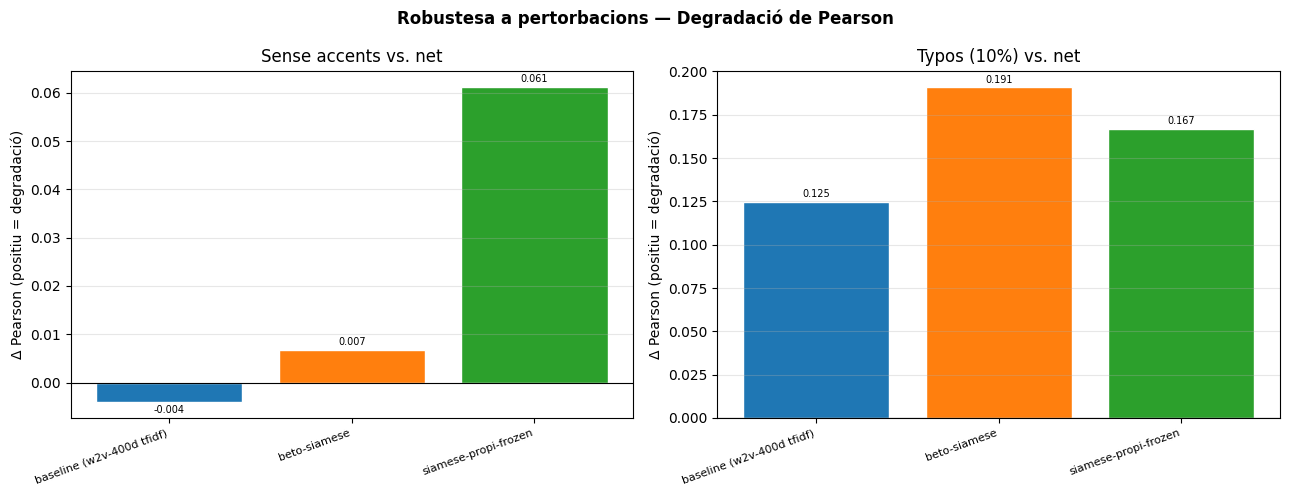

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Robustesa a pertorbacions — Degradació de Pearson", fontweight="bold")

colors_map = plt.cm.tab10.colors
for ax_idx, (delta_col, title) in enumerate([
    ("delta_no_acc", "Sense accents vs. net"),
    ("delta_typos",  "Typos (10%) vs. net"),
]):
    vals  = robustness_df[delta_col].values
    names = robustness_df["model"].values
    colors = [colors_map[i % 10] for i in range(len(names))]
    bars = axes[ax_idx].bar(names, vals, color=colors, edgecolor="white")
    axes[ax_idx].axhline(0, color="black", linewidth=0.8)
    axes[ax_idx].set_title(title)
    axes[ax_idx].set_ylabel("Δ Pearson (positiu = degradació)")
    axes[ax_idx].set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    axes[ax_idx].bar_label(bars, fmt="{:.3f}", fontsize=7, padding=2)
    axes[ax_idx].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("robustness_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Tasca 4 — Síntesi executiva

Resum d'una pantalla amb les xifres essencials de tot el treball: rànquings de Multi-SimLex (intrínseca) i Spanish STS (extrínseca), guanys arquitecturals, i degradació davant pertorbacions. La interpretació detallada es desenvolupa a l'informe.

In [ ]:
# ─── Headlines per a l'informe ──────────────────────────────────────────────

# Multi-SimLex: separar "propi" de "oficial" abans de seleccionar
best_simlex_propi   = (simlex_df[~simlex_df["model"].str.contains("oficial")]
                       .sort_values("spearman_rho", ascending=False).iloc[0])
best_simlex_oficial = (simlex_df[simlex_df["model"].str.contains("oficial")]
                       .sort_values("spearman_rho", ascending=False).iloc[0])

# Spanish STS: selecció del millor per família amb dev_pearson, mai amb test
best_baseline = (comp_df[comp_df["familia"].str.startswith("Baseline")]
                 .sort_values("dev_pearson", ascending=False).iloc[0])
best_siamese  = (comp_df[comp_df["familia"].str.startswith("Siamese")]
                 .sort_values("dev_pearson", ascending=False).iloc[0])

headlines = pd.DataFrame([
    {"tasca": "Multi-SimLex (Spearman)", "concepte": "Millor model propi",
     "model": best_simlex_propi["model"], "valor": best_simlex_propi["spearman_rho"]},
    {"tasca": "Multi-SimLex (Spearman)", "concepte": "Millor fastText oficial",
     "model": best_simlex_oficial["model"], "valor": best_simlex_oficial["spearman_rho"]},
    {"tasca": "Spanish STS (Pearson test)", "concepte": "Millor baseline (selecció per dev)",
     "model": f"{best_baseline['model']} ({best_baseline['configuracio']})",
     "valor": best_baseline["test_pearson"]},
    {"tasca": "Spanish STS (Pearson test)", "concepte": "Millor siamès (selecció per dev)",
     "model": best_siamese["model"], "valor": best_siamese["test_pearson"]},
    {"tasca": "Spanish STS (Pearson test)", "concepte": "BETO siamès",
     "model": "beto-siamese", "valor": test_bert},
    {"tasca": "Guany (Δ Pearson test)", "concepte": "Baseline FT propi → Siamès",
     "model": "—", "valor": gains.iloc[0]["guany"]},
    {"tasca": "Guany (Δ Pearson test)", "concepte": "Siamès estàtic → BETO",
     "model": "—", "valor": gains.iloc[1]["guany"]},
    {"tasca": "Robustesa (Δ Pearson)", "concepte": "Degradació mitjana sense accents",
     "model": "—", "valor": robustness_df["delta_no_acc"].mean()},
    {"tasca": "Robustesa (Δ Pearson)", "concepte": "Degradació mitjana amb typos 10%",
     "model": "—", "valor": robustness_df["delta_typos"].mean()},
])

display(headlines.style.format({"valor": "{:+.4f}"})
        .background_gradient(subset=["valor"], cmap="RdYlGn"))

,tasca,concepte,model,valor
0,Multi-SimLex (Spearman),Millor model propi,w2v-cbow-300d-all strict,+0.3316
1,Multi-SimLex (Spearman),Millor fastText oficial,ft-oficial-300d strict,+0.5193
2,Spanish STS (Pearson test),Millor baseline (selecció per dev),w2v-400d (tfidf),+0.5948
3,Spanish STS (Pearson test),Millor siamès (selecció per dev),siamese-propi-frozen,+0.5626
4,Spanish STS (Pearson test),BETO siamès,beto-siamese,+0.7315
5,Guany (Δ Pearson test),Baseline FT propi → Siamès,—,+0.0707
6,Guany (Δ Pearson test),Siamès estàtic → BETO,—,+0.1689
7,Robustesa (Δ Pearson),Degradació mitjana sense accents,—,+0.0213
8,Robustesa (Δ Pearson),Degradació mitjana amb typos 10%,—,+0.1608


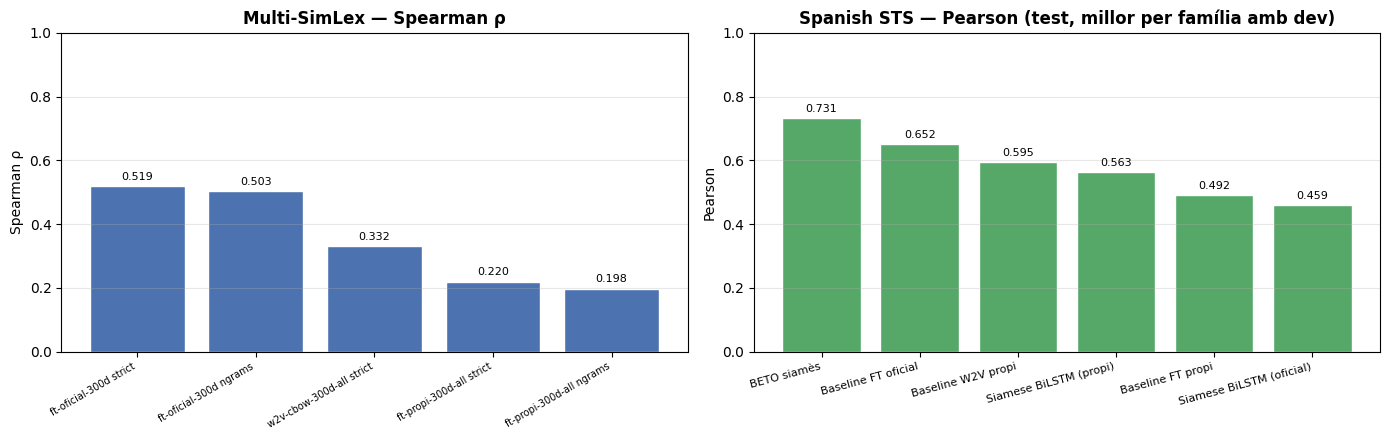

In [ ]:
# ─── Plot resum: rànquing Multi-SimLex vs Spanish STS (per família) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Multi-SimLex Spearman (rànquing complet, no implica selecció)
ax = axes[0]
sl = simlex_df.sort_values("spearman_rho", ascending=False)
bars = ax.bar(sl["model"], sl["spearman_rho"], color="#4C72B0", edgecolor="white")
ax.set_title("Multi-SimLex — Spearman ρ", fontweight="bold")
ax.set_ylabel("Spearman ρ"); ax.set_ylim(0, 1)
ax.bar_label(bars, fmt="{:.3f}", fontsize=8, padding=3)
ax.tick_params(axis="x", labelsize=7, rotation=30)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
ax.grid(axis="y", alpha=0.3)

# Spanish STS Pearson — millor per família (SELECCIÓ PER DEV, mostra de test)
ax = axes[1]
best_per_family = (comp_df.sort_values("dev_pearson", ascending=False)
                          .groupby("familia", as_index=False).first()
                          .sort_values("test_pearson", ascending=False))
bars = ax.bar(best_per_family["familia"], best_per_family["test_pearson"],
              color="#55A868", edgecolor="white")
ax.set_title("Spanish STS — Pearson (test, millor per família amb dev)", fontweight="bold")
ax.set_ylabel("Pearson"); ax.set_ylim(0, 1)
ax.bar_label(bars, fmt="{:.3f}", fontsize=8, padding=3)
ax.tick_params(axis="x", labelsize=8, rotation=15)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("executive_summary.png", dpi=150, bbox_inches="tight")
plt.show()